# Set-up

In [1]:
%%capture
!pip install torch transformers
!pip install -U "huggingface_hub[cli]"
!pip install accelerate

# (recommended inside a fresh venv/conda env)
!pip uninstall -y huggingface_hub
!pip install "huggingface-hub>=0.34.0,<1.0"
# sanity check
!python -c "import transformers, huggingface_hub as h; print('transformers', transformers.__version__, 'hub', h.__version__)"

In [2]:
import os
os.environ["HF_HOME"] = "./hf"
os.environ["HF_HUB_CACHE"] = "./hf/hub"
os.environ['PATH'] += ':/storage/home/hcoda1/9/kzhang430/.local/bin'
os.environ.setdefault("HF_HOME", "./hf")
os.environ.setdefault("HF_HUB_CACHE", "./hf/hub")
os.environ.setdefault("HF_DATASETS_CACHE", "./hf/datasets")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import re
import json
from huggingface_hub import login

In [3]:
from huggingface_hub import HfFolder
HfFolder.save_token(os.environ["HF_TOKEN"])

In [4]:
!hf auth whoami

user:  wristycargo


In [5]:
!pwd

/storage/scratch1/9/kzhang430


# Experiment 1: Replicating paper + whole-expression extension

In [4]:
import json, math, re
from collections import Counter
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

INT_RE = re.compile(r"^\s*([+-]?\d+)")
OP_MAP = {"×": "*", "x": "*", "*": "*", "÷": "/", "/": "/", "+": "+", "-": "-"}

def normalize_op(op: str) -> str:
    return OP_MAP.get(op.strip(), op.strip())

def make_prompt(a: int, op: str, b: int, spaced=True) -> str:
    op = normalize_op(op)
    return f"{a} {op} {b} =" if spaced else f"{a}{op}{b}="

def safe_int_from_text(s: str):
    m = INT_RE.match(s)
    return int(m.group(1)) if m else None

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            rows.append(r)
    return rows

def build_rows_and_freq(rows, spaced_prompt=True):
    freq_a, freq_b, freq_c, freq_prompt = Counter(), Counter(), Counter(), Counter()
    out = []
    for r in rows:
        a, b, c = int(r["a"]), int(r["b"]), int(r["c"])
        op = normalize_op(r["op"])
        prompt = make_prompt(a, op, b, spaced=spaced_prompt)
        freq_a[a] += 1
        freq_b[b] += 1
        freq_c[c] += 1
        freq_prompt[prompt] += 1
        out.append({"row_index": r.get("row_index"), "a": a, "op": op, "b": b, "c": c, "prompt": prompt})
    return out, freq_a, freq_b, freq_c, freq_prompt

def attach_freq_features(examples, freq_a, freq_b, freq_c, freq_prompt):
    for ex in examples:
        ex["freq_a"] = freq_a[ex["a"]]
        ex["freq_b"] = freq_b[ex["b"]]
        ex["freq_c"] = freq_c[ex["c"]]
        ex["freq_prompt"] = freq_prompt[ex["prompt"]]
        ex["log_freq_a"] = math.log10(1 + ex["freq_a"])
        ex["log_freq_b"] = math.log10(1 + ex["freq_b"])
        ex["log_freq_c"] = math.log10(1 + ex["freq_c"])
        ex["log_freq_prompt"] = math.log10(1 + ex["freq_prompt"])
    return examples

## Evaluation set

In [20]:
# JSONL_PATH = "./data/pile_arith_matches_full_copy_backup.jsonl" 
JSONL_PATH = "./pile_arith_matches_full_fresh_deduped.jsonl" 
SPACED_PROMPTS = True           # match your formatting choice
EVAL_N = 10000
SEED = 0

raw = load_jsonl(JSONL_PATH)
rows, freq_a, freq_b, freq_c, freq_prompt = build_rows_and_freq(raw, spaced_prompt=SPACED_PROMPTS)

unique_prompts = list({r["prompt"]: r for r in rows}.values())  # one row per unique prompt
rng = np.random.default_rng(SEED)
idx = rng.choice(len(unique_prompts), size=min(EVAL_N, len(unique_prompts)), replace=False)
eval_rows = [unique_prompts[i].copy() for i in idx]

# Optional: if division might be non-integer or weird, filter it out:
# eval_rows = [ex for ex in eval_rows if not (ex["op"] == "/" and ex["a"] % ex["b"] != 0)]

eval_rows = attach_freq_features(eval_rows, freq_a, freq_b, freq_c, freq_prompt)

df_eval = pd.DataFrame(eval_rows)
df_eval.head()

,row_index,a,op,b,c,prompt,freq_a,freq_b,freq_c,freq_prompt,log_freq_a,log_freq_b,log_freq_c,log_freq_prompt
0,87278154,8088,/,8,1011,8088 / 8 =,1,6642,21,1,0.301030,3.822364,1.342423,0.301030
1,86916567,10316,+,1084,11400,10316 + 1084 =,1,1,1,1,0.301030,0.301030,0.301030,0.301030
2,134111686,9,-,7,2,9 - 7 =,3708,5566,15071,93,3.569257,3.745621,4.178171,1.973128
3,89510679,115,-,5,110,115 - 5 =,61,10853,200,1,1.792392,4.035590,2.303196,0.301030
4,74267756,521,-,31,490,521 - 31 =,4,303,32,1,0.698970,2.482874,1.518514,0.301030


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAMES = [
    "EleutherAI/pythia-70m-deduped",
    "EleutherAI/pythia-160m-deduped",
    "EleutherAI/pythia-410m-deduped",
    "EleutherAI/pythia-1b-deduped",
    "EleutherAI/pythia-1.4b-deduped",
    "EleutherAI/pythia-2.8b-deduped",
    "EleutherAI/pythia-6.9b-deduped",
    "EleutherAI/pythia-12b-deduped",
]

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAMES[0], use_fast=True, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [7]:
@torch.inference_mode()
def eval_greedy(model, tokenizer, df_eval, batch_size=32, max_new_tokens=8):
    prompts = (df_eval["prompt"] + " ").tolist()
    targets = df_eval["c"].apply(int).tolist()

    correct = 0
    out_rows = []

    for i in tqdm(range(0, len(prompts), batch_size), desc="greedy"):
        batch_prompts = prompts[i:i+batch_size]
        batch_targets = targets[i:i+batch_size]

        enc = tokenizer(batch_prompts, return_tensors="pt", padding=True)
        enc = {k: v.to(model.device) for k, v in enc.items()}

        gen = model.generate(
            **enc,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

        input_len = enc["input_ids"].shape[1]  # padded input length
        for bp, tgt, seq in zip(batch_prompts, batch_targets, gen):
            suffix_ids = seq[input_len:]
            suffix_txt = tokenizer.decode(suffix_ids, skip_special_tokens=True)

            pred = safe_int_from_text(suffix_txt)
            is_correct = (pred == tgt)
            correct += int(is_correct)

            out_rows.append({
                "prompt": bp.strip(),
                "target": tgt,
                "pred": pred,
                "gen_suffix": suffix_txt[:80],
                "is_correct": is_correct,
            })

    acc = correct / max(1, len(prompts))
    return acc, pd.DataFrame(out_rows)

In [30]:
all_results = []

for name in MODEL_NAMES:
    print("\n=== ", name, " ===")

    model = AutoModelForCausalLM.from_pretrained(
        name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    model.eval()

    acc, df_pred = eval_greedy(model, tokenizer, df_eval, batch_size=32)
    print("accuracy:", acc)

    # merge model outputs with your per-example freq features
    df = df_eval.merge(df_pred, left_on="prompt", right_on="prompt", how="left")
    df["model"] = name
    df["model_acc_overall"] = acc
    all_results.append(df)

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

results = pd.concat(all_results, ignore_index=True)
results.to_csv("pythia_freq_results.csv", index=False)
results.head()


===  EleutherAI/pythia-70m-deduped  ===


logprob:   0%|          | 0/313 [00:00<?, ?it/s]

ValueError: too many values to unpack (expected 2)

In [39]:
results[results['is_correct']].iloc[500:590]

,row_index,a,op,b,c,prompt,freq_a,freq_b,freq_c,freq_prompt,log_freq_a,log_freq_b,log_freq_c,log_freq_prompt,target,pred,gen_suffix,is_correct,model,model_acc_overall
43292,63420791,1930,-,1930,0,1930 - 1930 =,2,2,12269,1,0.477121,0.477121,4.088845,0.301030,0,0.0,\n0.00\n\n1930 -,True,EleutherAI/pythia-1.4b-deduped,0.0178
43387,74931439,1218,-,1218,0,1218 - 1218 =,2,3,12269,1,0.477121,0.602060,4.088845,0.301030,0,0.0,"\n0x7f0b,",True,EleutherAI/pythia-1.4b-deduped,0.0178
43659,131796495,188,-,190,-2,188 - 190 =,28,25,3371,1,1.462398,1.414973,3.527888,0.301030,-2,-2.0,\n-2*sqrt(2),True,EleutherAI/pythia-1.4b-deduped,0.0178
43786,108007148,473,-,475,-2,473 - 475 =,7,11,3371,1,0.903090,1.079181,3.527888,0.301030,-2,-2.0,\n-2*sqrt(2),True,EleutherAI/pythia-1.4b-deduped,0.0178
43819,133205452,1,*,0,0,1 * 0 =,25718,8250,12269,138,4.410254,3.916507,4.088845,2.143015,0,0.0,\n0 * 0 = 0\n0,True,EleutherAI/pythia-1.4b-deduped,0.0178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48116,91390146,440,-,440,0,440 - 440 =,32,23,12269,1,1.518514,1.380211,4.088845,0.301030,0,0.0,\n0.0\n\nI have,True,EleutherAI/pythia-1.4b-deduped,0.0178
48199,134240859,12,-,14,-2,12 - 14 =,3017,1127,3371,18,3.479719,3.052309,3.527888,1.278754,-2,-2.0,\n-2.5\nWhat is,True,EleutherAI/pythia-1.4b-deduped,0.0178
48202,120544938,85,-,85,0,85 - 85 =,117,105,12269,3,2.071882,2.025306,4.088845,0.602060,0,0.0,\n0.5\nLet n =,True,EleutherAI/pythia-1.4b-deduped,0.0178
48210,59858851,260,-,260,0,260 - 260 =,53,13,12269,1,1.732394,1.146128,4.088845,0.301030,0,0.0,\n0.5\n\nThe first,True,EleutherAI/pythia-1.4b-deduped,0.0178


In [40]:
import numpy as np
import pandas as pd

df = results.copy()

# Make sure binary is 0/1
df["y"] = df["is_correct"].astype(int)

# Digits (absolute value so -3 has 1 digit)
df["digits_a"] = df["a"].abs().astype(str).str.len()
df["digits_b"] = df["b"].abs().astype(str).str.len()
df["digits_c"] = df["c"].abs().astype(str).str.len()

# Optional: carry count for addition, borrow count for subtraction
def carry_count_add(a, b):
    a, b = abs(int(a)), abs(int(b))
    carry = 0
    c = 0
    while a > 0 or b > 0:
        da, db = a % 10, b % 10
        if da + db + c >= 10:
            carry += 1
            c = 1
        else:
            c = 0
        a //= 10; b //= 10
    return carry

def borrow_count_sub(a, b):
    # counts borrows in a - b (assuming standard grade-school subtraction on abs values)
    a, b = abs(int(a)), abs(int(b))
    borrow = 0
    br = 0
    while a > 0 or b > 0:
        da, db = a % 10, b % 10
        da -= br
        if da < db:
            borrow += 1
            br = 1
        else:
            br = 0
        a //= 10; b //= 10
    return borrow

df["carry_add"] = np.where(df["op"] == "+", df.apply(lambda r: carry_count_add(r["a"], r["b"]), axis=1), 0)
df["borrow_sub"] = np.where(df["op"] == "-", df.apply(lambda r: borrow_count_sub(r["a"], r["b"]), axis=1), 0)

# If you have parse failures: treat them as incorrect (y=0) or add a separate flag
df["pred_is_nan"] = df["pred"].isna().astype(int)

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

def fit_logit_for_model(df, model_name, freq_col="log_freq_prompt"):
    d = df[df["model"] == model_name].copy()

    # Basic spec: frequency + controls
    formula = f"y ~ {freq_col} + C(op) + digits_a + digits_b + carry_add + borrow_sub"
    m = smf.glm(formula=formula, data=d, family=sm.families.Binomial()).fit(cov_type="HC3")
    return m

models = sorted(df["model"].unique())

fits = {}
for mn in models:
    fits[mn] = fit_logit_for_model(df, mn, freq_col="log_freq_prompt")
    print("\n", mn)
    print(fits[mn].summary().tables[1])

In [ ]:
import numpy as np

mn = models[0]  # pick one
coef = fits[mn].params["log_freq_prompt"]
oratio = np.exp(coef)
print("Odds ratio for +1 in log_freq_prompt:", oratio)

In [20]:
import re
import numpy as np

def pythia_size_m(name: str) -> float:
    """
    Returns size in millions of parameters (e.g., 70m -> 70, 1.4b -> 1400).
    If it can't parse, returns +inf so it goes last.
    """
    s = name.lower()
    m = re.search(r"pythia-(\d+(?:\.\d+)?)(m|b)", s)
    if not m:
        return float("inf")
    val = float(m.group(1))
    unit = m.group(2)
    return val if unit == "m" else val * 1000.0

# sort from smallest -> largest
models_sorted = sorted(df["model"].unique(), key=pythia_size_m)

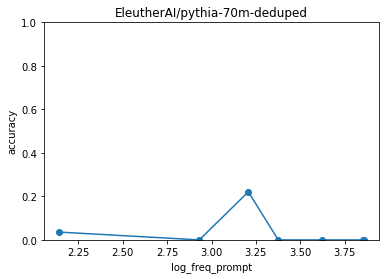

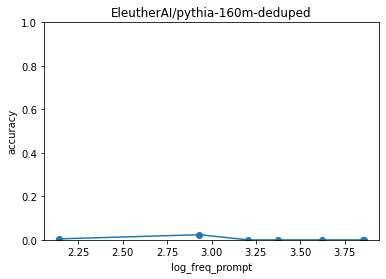

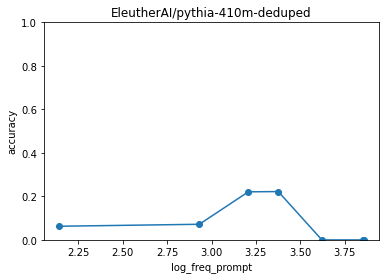

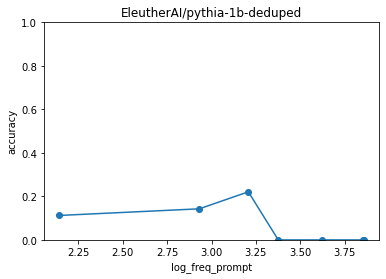

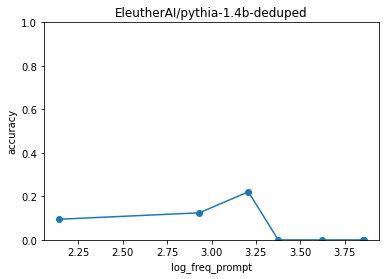

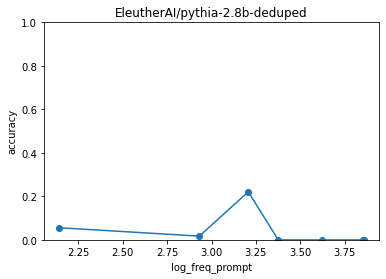

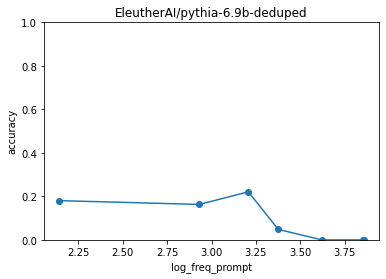

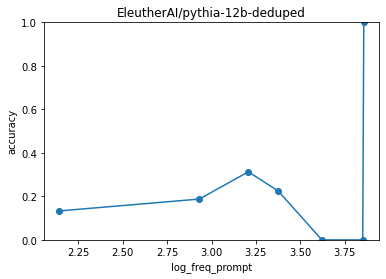

In [21]:
import matplotlib.pyplot as plt

def binned_curve(d, x="log_freq_prompt", bins=10):
    xs = d[x].to_numpy()
    ys = d["y"].to_numpy()
    qs = np.quantile(xs, np.linspace(0, 1, bins+1))
    qs = np.unique(qs)
    if len(qs) < 3:
        return None
    b = np.digitize(xs, qs[1:-1], right=True)
    xmean = [xs[b==k].mean() for k in range(b.min(), b.max()+1)]
    ymean = [ys[b==k].mean() for k in range(b.min(), b.max()+1)]
    n = [int((b==k).sum()) for k in range(b.min(), b.max()+1)]
    return xmean, ymean, n

for mn in models_sorted:
    d = df[df["model"] == mn]
    out = binned_curve(d, bins=12)
    if out is None:
        continue
    xmean, ymean, n = out
    plt.figure()
    plt.plot(xmean, ymean, marker="o")
    plt.ylim(0, 1)
    plt.title(mn)
    plt.xlabel("log_freq_prompt")
    plt.ylabel("accuracy")
    plt.show()

In [22]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

def add_quantile_bins(d, x="log_freq_prompt", bins=12):
    d = d.copy()
    xs = d[x].to_numpy()

    edges = np.quantile(xs, np.linspace(0, 1, bins+1))
    edges = np.unique(edges)  # collapses if many duplicates
    if len(edges) < 3:
        raise ValueError("Not enough distinct x values to bin.")

    # bin index in [0, ..., len(edges)-2]
    bin_id = np.digitize(xs, edges[1:-1], right=True)
    d["bin"] = bin_id
    d["bin_lo"] = edges[bin_id]
    d["bin_hi"] = edges[bin_id + 1]
    return d, edges

def bin_summary(d, x="log_freq_prompt"):
    g = d.groupby("bin").agg(
        n=("y","size"),
        acc=("y","mean"),
        n_unique_prompts=("prompt","nunique"),
        xmean=(x,"mean"),
        mean_freq=("freq_prompt","mean"),
    ).reset_index()

    # Wilson 95% CI for accuracy in each bin
    lo, hi = [], []
    for _, r in g.iterrows():
        k = int(round(r["acc"] * r["n"]))
        l, h = proportion_confint(k, int(r["n"]), alpha=0.05, method="wilson")
        lo.append(l); hi.append(h)
    g["acc_lo"] = lo
    g["acc_hi"] = hi
    return g.sort_values("xmean")

# pick one model to inspect
mn = "EleutherAI/pythia-12b-deduped"
d = df[df["model"] == mn].copy()
d["y"] = d["is_correct"].astype(int)

d_b, edges = add_quantile_bins(d, bins=12)
summ = bin_summary(d_b)
summ

,bin,n,acc,n_unique_prompts,xmean,mean_freq,acc_lo,acc_hi
0,0,38307,0.133292,4078,2.143681,230.030778,1.299246e-01,0.136732
1,1,38862,0.187716,27,2.931351,882.083295,1.838641e-01,0.191629
2,2,39122,0.313097,7,3.207169,1628.729922,3.085206e-01,0.317711
3,3,36851,0.224716,3,3.375750,2409.290087,2.204830e-01,0.229006
4,4,48400,0.000000,1,3.621280,4180.000000,-6.776264e-21,0.000079
5,5,125316,0.000000,1,3.851258,7099.000000,0.000000e+00,0.000031
6,6,121104,1.000000,1,3.857152,7196.000000,9.999683e-01,1.000000


In [23]:
sus_bin = summ.sort_values("acc", ascending=False).iloc[0]["bin"]
sus_bin = int(sus_bin)

top = (d_b[d_b["bin"] == sus_bin]
       .groupby("prompt")
       .agg(n=("prompt","size"),
            freq=("freq_prompt","first"),
            acc=("y","mean"),
            a=("a","first"), op=("op","first"), b=("b","first"), c=("c","first"))
       .sort_values(["freq","n"], ascending=False)
       .head(30))
top

,n,freq,acc,a,op,b,c
prompt,,,,,,,
1 + 1 =,121104,7196,1.0,1,+,1,2


- scatter plot:
    log frequency vs accuracy for each problem.
    
- separately analyse table facts (12x12...)


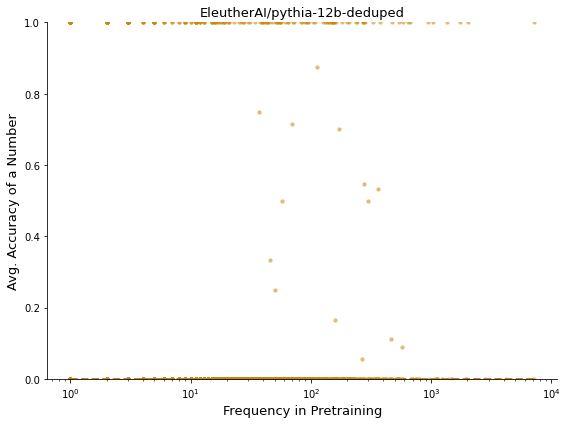

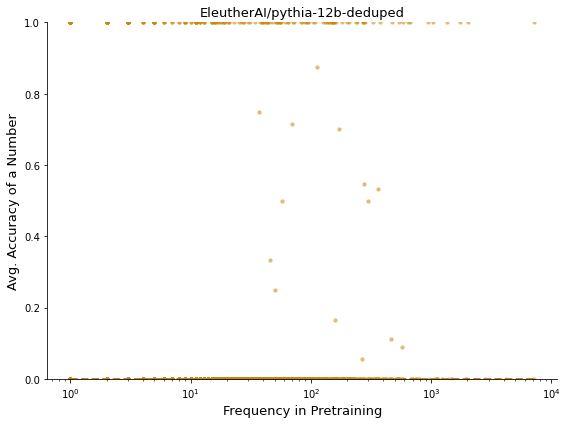

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
import statsmodels.api as sm

def scatter_freq_vs_acc(df, model_name=None, freq_col="freq_prompt", figsize=(8, 6)):
    """
    Scatter plot of pretraining frequency vs. per-prompt accuracy,
    styled like the reference image.

    Parameters
    ----------
    df          : results DataFrame with columns [prompt, freq_prompt, is_correct, model]
    model_name  : if None, averages accuracy across all models
    freq_col    : raw frequency column (plotted on log x-axis)
    """
    d = df.copy()
    if model_name is not None:
        d = d[d["model"] == model_name]

    # One row per unique prompt
    per_prompt = (
        d.groupby("prompt")
         .agg(
             freq=(freq_col, "first"),
             acc=("is_correct", "mean"),
             n=("is_correct", "count"),
         )
         .reset_index()
    )

    x = per_prompt["freq"].to_numpy(dtype=float)
    y = per_prompt["acc"].to_numpy(dtype=float)

    # --- LOWESS trend + confidence band (bootstrap) ---
    log_x = np.log10(x)
    order = np.argsort(log_x)
    lx_sorted = log_x[order]
    y_sorted  = y[order]

    lowess = sm.nonparametric.lowess(y_sorted, lx_sorted, frac=0.4, return_sorted=True)
    lx_smooth, y_smooth = lowess[:, 0], lowess[:, 1]

    # Bootstrap 95% CI around LOWESS
    n_boot = 200
    boot_curves = []
    rng = np.random.default_rng(42)
    for _ in range(n_boot):
        idx = rng.integers(0, len(lx_sorted), len(lx_sorted))
        b = sm.nonparametric.lowess(y_sorted[idx], lx_sorted[idx], frac=0.4, return_sorted=True)
        boot_curves.append(np.interp(lx_smooth, b[:, 0], b[:, 1]))
    boot_curves = np.array(boot_curves)
    ci_lo = np.percentile(boot_curves, 2.5, axis=0)
    ci_hi = np.percentile(boot_curves, 97.5, axis=0)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(x, y, color="#C8860A", alpha=0.55, s=18, linewidths=0, zorder=2)

    smooth_x = 10 ** lx_smooth
    ax.plot(smooth_x, y_smooth, color="#C8860A", linewidth=2, linestyle="--", zorder=3)
    ax.fill_between(smooth_x, ci_lo, ci_hi, color="#C8860A", alpha=0.18, zorder=1)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frequency in Pretraining", fontsize=13)
    ax.set_ylabel("Avg. Accuracy of a Number", fontsize=13)
    title = model_name if model_name else "All models (averaged)"
    ax.set_title(title, fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig


# --- Usage ---
# Single model:
scatter_freq_vs_acc(results, model_name="EleutherAI/pythia-12b-deduped")

# Averaged across all models:
# scatter_freq_vs_acc(results)

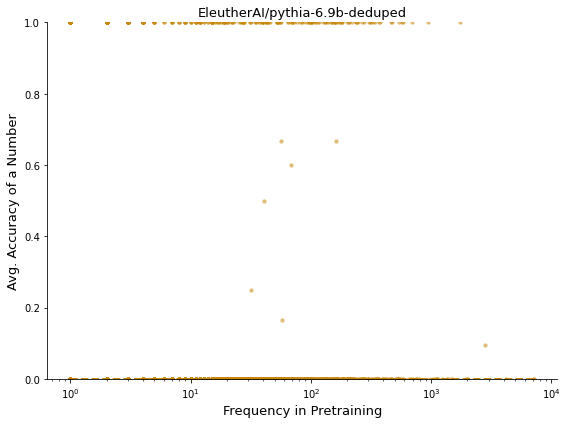

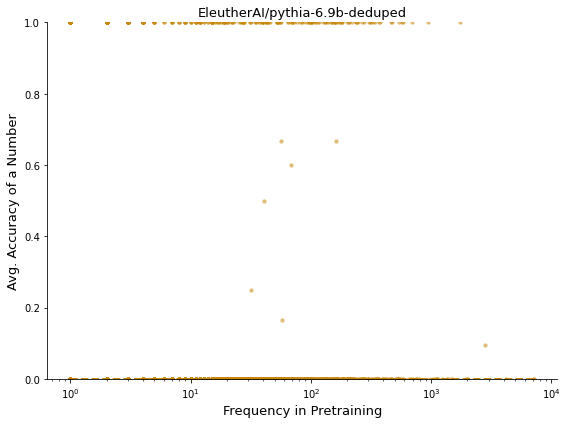

In [26]:
scatter_freq_vs_acc(results, model_name="EleutherAI/pythia-6.9b-deduped")

In [29]:
results["freq_prompt"].describe()

count    3.583696e+06
mean     4.819583e+03
std      2.750061e+03
min      1.000000e+00
25%      1.957000e+03
50%      7.099000e+03
75%      7.196000e+03
max      7.196000e+03
Name: freq_prompt, dtype: float64

In [30]:
results["freq_prompt"].value_counts().head(20)

7099    1002528
7196     968832
4180     387200
2808     150152
1957      83232
1962      78408
1737      69192
2035      66248
1502      43808
1468      43808
1135      29768
1349      28800
1387      23328
1082      23328
1106      23328
1111      22472
942       22472
1219      20808
1120      17672
965       15488
Name: freq_prompt, dtype: int64

In [31]:
print(results[["prompt", "freq_prompt", "row_index"]].drop_duplicates("prompt").head(20).to_string())

                prompt  freq_prompt  row_index
0              4 - 1 =          748   91018771
43             1 + 1 =         7196  122184662
391          12 + 10 =           29  121785635
394          1 * 512 =         4180   16100266
614            2 + 2 =         7099  124344713
1316         60 - 50 =            9   90172168
1317         50 + 50 =           54   61464213
1319          30 + 5 =           12    9832904
1320  214026205 - 16 =            1  125894806
1321           3 * 8 =          157   78705087
1332         480 / 6 =            2   46390525
1333     4654726 / 2 =            1  120103564
1334         36 - 36 =           15   75035214
1336           4 - 2 =          685   45097166
1370           5 - 3 =          514   48383023
1389           3 / 1 =           58   55526500
1393      1377 + 765 =            1  100325225
1394        100 * 10 =           44   28671546
1396         61 - 24 =            2  111148310
1397           1 + 6 =          300   75526880


/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


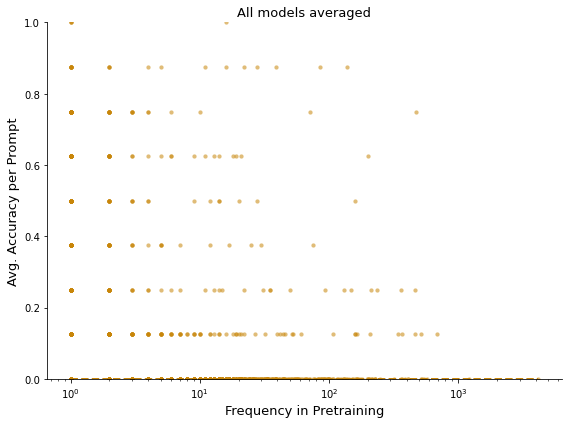

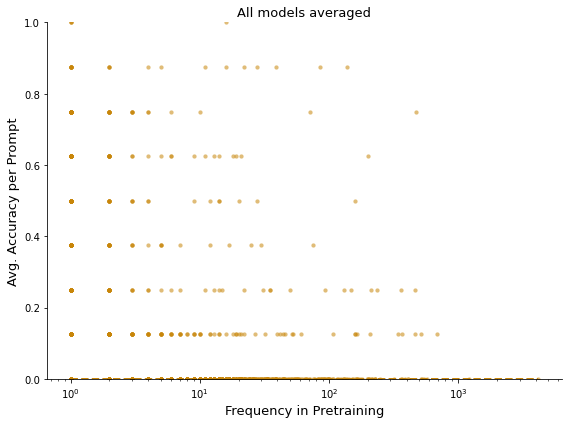

In [77]:
def scatter_freq_vs_acc(df, figsize=(8, 6)):
    # Average accuracy across ALL models for each prompt
    per_prompt = (
        df.groupby("prompt")
          .agg(
              freq=("freq_prompt", "first"),
              acc=("is_correct", "mean"),   # mean across all models
              n=("is_correct", "count"),    # how many model evaluations
          )
          .reset_index()
    )

    # Optional: filter to prompts seen by at least 2 models for more stable estimates
    per_prompt = per_prompt[per_prompt["n"] >= 2]

    x = per_prompt["freq"].to_numpy(dtype=float)
    y = per_prompt["acc"].to_numpy(dtype=float)
    
    

    log_x = np.log10(x)
    order = np.argsort(log_x)
    lx_sorted, y_sorted = log_x[order], y[order]
    lowess = sm.nonparametric.lowess(y_sorted, lx_sorted, frac=0.75, return_sorted=True)
    lx_smooth, y_smooth = lowess[:, 0], lowess[:, 1]

    rng = np.random.default_rng(42)
    boot_curves = []
    for _ in range(200):
        idx = rng.integers(0, len(lx_sorted), len(lx_sorted))
        b = sm.nonparametric.lowess(y_sorted[idx], lx_sorted[idx], frac=0.55, return_sorted=True)
        boot_curves.append(np.interp(lx_smooth, b[:, 0], b[:, 1]))
        
    ci_lo = np.percentile(boot_curves, 2.5,  axis=0)
    ci_hi = np.percentile(boot_curves, 97.5, axis=0)

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, y, color="#C8860A", alpha=0.55, s=18, linewidths=0, zorder=2)
    ax.plot(10**lx_smooth, y_smooth, color="#C8860A", linewidth=2, linestyle="--", zorder=3)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frequency in Pretraining", fontsize=13)
    ax.set_ylabel("Avg. Accuracy per Prompt", fontsize=13)
    ax.set_title("All models averaged", fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig

scatter_freq_vs_acc(results)

/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


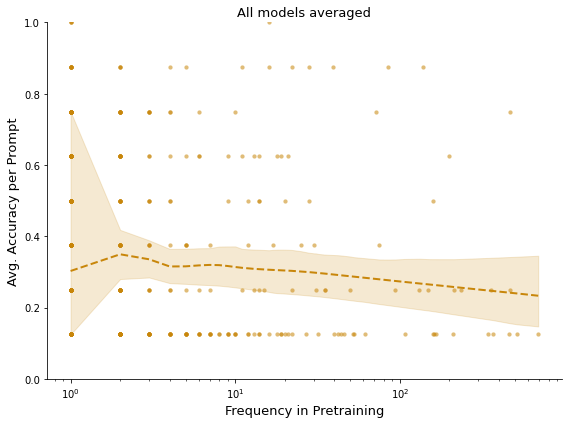

In [69]:
def scatter_freq_vs_acc(df, figsize=(8, 6)):
    # Average accuracy across ALL models for each prompt
    per_prompt = (
        df.groupby("prompt")
          .agg(
              freq=("freq_prompt", "first"),
              acc=("is_correct", "mean"),   # mean across all models
              n=("is_correct", "count"),    # how many model evaluations
          )
          .reset_index()
    )

    # Optional: filter to prompts seen by at least 2 models for more stable estimates
    per_prompt = per_prompt[per_prompt["acc"] > 0]
    
    

    x = per_prompt["freq"].to_numpy(dtype=float)
    y = per_prompt["acc"].to_numpy(dtype=float)
    
    

    log_x = np.log10(x)
    order = np.argsort(log_x)
    lx_sorted, y_sorted = log_x[order], y[order]
    lowess = sm.nonparametric.lowess(y_sorted, lx_sorted, frac=0.75, return_sorted=True)
    lx_smooth, y_smooth = lowess[:, 0], lowess[:, 1]

    rng = np.random.default_rng(42)
    boot_curves = []
    for _ in range(200):
        idx = rng.integers(0, len(lx_sorted), len(lx_sorted))
        b = sm.nonparametric.lowess(y_sorted[idx], lx_sorted[idx], frac=0.55, return_sorted=True)
        boot_curves.append(np.interp(lx_smooth, b[:, 0], b[:, 1]))
        
    ci_lo = np.percentile(boot_curves, 2.5,  axis=0)
    ci_hi = np.percentile(boot_curves, 97.5, axis=0)

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, y, color="#C8860A", alpha=0.55, s=18, linewidths=0, zorder=2)
    ax.plot(10**lx_smooth, y_smooth, color="#C8860A", linewidth=2, linestyle="--", zorder=3)
    ax.fill_between(10**lx_smooth, ci_lo, ci_hi, color="#C8860A", alpha=0.18, zorder=1)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frequency in Pretraining", fontsize=13)
    ax.set_ylabel("Avg. Accuracy per Prompt", fontsize=13)
    ax.set_title("All models averaged", fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    # return fig

scatter_freq_vs_acc(results)

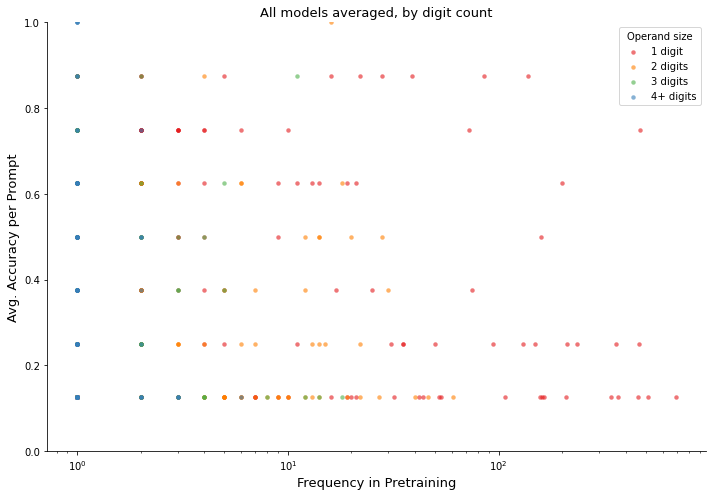

In [66]:
def scatter_freq_vs_acc_by_digits(df, figsize=(10, 7)):
    per_prompt = (
        df.groupby("prompt")
          .agg(
              freq=("freq_prompt", "first"),
              acc=("is_correct", "mean"),
              op=("op", "first"),
              a=("a", "first"),
          )
          .reset_index()
    )
    per_prompt = per_prompt[per_prompt["acc"] > 0]
    per_prompt["digits_a"] = per_prompt["a"].abs().astype(str).str.len()

    # Group digit counts into buckets for legibility
    per_prompt["digit_group"] = pd.cut(
        per_prompt["digits_a"],
        bins=[0, 1, 2, 3, 20],
        labels=["1 digit", "2 digits", "3 digits", "4+ digits"]
    )

    colors = {"1 digit": "#e41a1c", "2 digits": "#ff7f00",
              "3 digits": "#4daf4a", "4+ digits": "#377eb8"}

    fig, ax = plt.subplots(figsize=figsize)
    for grp, gdf in per_prompt.groupby("digit_group"):
        ax.scatter(gdf["freq"], gdf["acc"],
                   color=colors[str(grp)], alpha=0.6, s=20,
                   linewidths=0, label=str(grp), zorder=2)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frequency in Pretraining", fontsize=13)
    ax.set_ylabel("Avg. Accuracy per Prompt", fontsize=13)
    ax.set_title("All models averaged, by digit count", fontsize=13)
    ax.legend(title="Operand size")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

scatter_freq_vs_acc_by_digits(results)

- fixed sampling to get eval set - instead of sampling the entire corpus (which will result in overwhelming majority being simple questions like 1+1=2), we sample from the set of the corpus (so unique rows)

## Multiplication

In [78]:
mult = results[results["op"] == "*"].copy()
times_tables = mult[(mult["a"] <= 12) & (mult["b"] <= 12)]
non_tables = mult[~((mult["a"] <= 12) & (mult["b"] <= 12))]

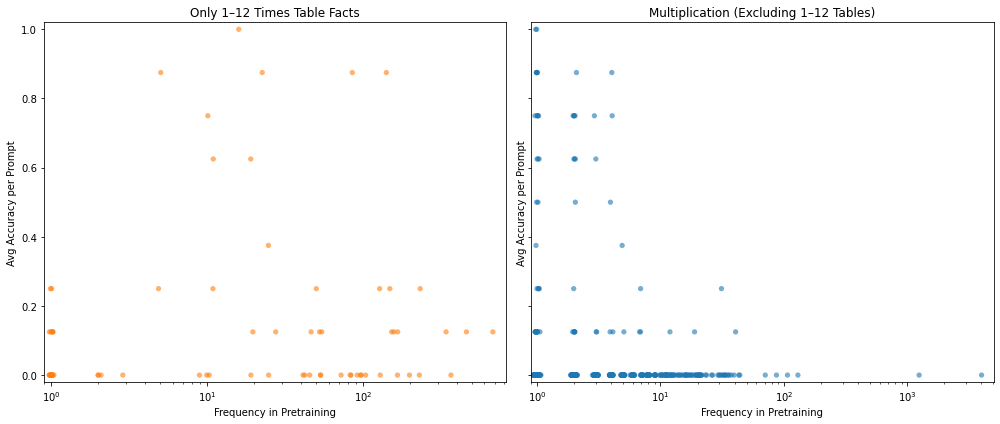

In [82]:
# Paste this into your notebook (assumes `results` dataframe exists with columns:
# "op", "a", "b", "prompt", "freq_prompt", "is_correct")

import numpy as np
import matplotlib.pyplot as plt

# 1. filter multiplications
mult = results[results["op"] == "*"].copy()

# 2. times tables (1-12) and the complement
times_tables = mult[(mult["a"] <= 12) & (mult["b"] <= 12)].copy()
non_tables  = mult[~((mult["a"] <= 12) & (mult["b"] <= 12))].copy()

# helper to compute frequency and mean accuracy per prompt
def grouped_freq_acc(df):
    g = (df.groupby("prompt")
         .agg(freq_prompt=("freq_prompt", "first"),
              accuracy=("is_correct", "mean"),
              n_examples=("is_correct", "size"))
         .reset_index())
    # drop invalid freqs
    g = g[~g["freq_prompt"].isna()].copy()
    # ensure freq >= 1 so log scale is defined
    g["freq_plot"] = g["freq_prompt"].clip(lower=1).astype(float)
    return g

gt = grouped_freq_acc(times_tables)
gn = grouped_freq_acc(non_tables)

# 3. Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

def plot_panel(ax, gdf, title, color="C0"):
    if gdf.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xscale("log")
        ax.set_xlabel("Frequency in Pretraining")
        ax.set_ylabel("Avg Accuracy per Prompt")
        ax.set_title(title)
        return

    # jitter to reduce overplotting for identical freq points (small relative jitter)
    jitter = np.random.normal(0, 0.02, size=len(gdf))
    x_jittered = gdf["freq_plot"] * (1 + jitter)

    ax.scatter(x_jittered, gdf["accuracy"], alpha=0.6, s=28, color=color, edgecolors="none")
    ax.set_xscale("log")
    ax.set_xlabel("Frequency in Pretraining")
    ax.set_ylabel("Avg Accuracy per Prompt")
    ax.set_title(title)
    # nice axis limits
    ax.set_xlim(0.9, max(10, gdf["freq_plot"].max() * 1.2))
    ax.set_ylim(-0.02, 1.02)
    # optional: show a small median marker binned by freq if you want
    # bins = np.logspace(np.log10(1), np.log10(ax.get_xlim()[1]), 8)
    # import scipy.stats as st
    # medx = []
    # medy = []
    # for i in range(len(bins)-1):
    #     sel = gdf[(gdf["freq_plot"] >= bins[i]) & (gdf["freq_plot"] < bins[i+1])]
    #     if len(sel):
    #         medx.append(sel["freq_plot"].median())
    #         medy.append(sel["accuracy"].median())
    # if medx:
    #     ax.plot(medx, medy, marker="o", linestyle="-", color="k", markersize=4)

# left: only table facts
plot_panel(axes[0], gt, "Only 1–12 Times Table Facts", color="tab:orange")

# right: everything except table facts
plot_panel(axes[1], gn, "Multiplication (Excluding 1–12 Tables)", color="tab:blue")

plt.tight_layout()
plt.show()

# Actual replication of paper

## By frequency of x1

In [4]:
import json, math, re, random
from collections import Counter
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ── 1. LOAD JSONL AND BUILD OPERAND FREQUENCIES ──────────────────────────────

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

JSONL_PATH = "./pile_arith_matches_full_fresh_deduped.jsonl"
raw = load_jsonl(JSONL_PATH)

# Count how often each number appears as operand 'a' across the full corpus
# This is our proxy for Pile unigram frequency
freq_a = Counter()
for r in raw:
    freq_a[int(r["a"])] += 1

print(f"Loaded {len(raw)} rows. Unique values of a: {len(freq_a)}")
print(f"Freq range: {min(freq_a.values())} – {max(freq_a.values())}")


# ── 2. BUILD EVAL SET: x1 in 0-99, x2 in 0-99, per operator ─────────────────

OPS = ["+", "-", "*", "/"]   # now includes division

def is_valid_problem(a, op, b):
    if op in {"+", "-", "*"}:
        return True
    if op == "/":
        return b != 0 and a % b == 0   # integer division only
    return False

def make_answer(a, op, b):
    if op == "+":
        return a + b
    if op == "-":
        return a - b
    if op == "*":
        return a * b
    if op == "/":
        if b == 0 or a % b != 0:
            raise ValueError(f"Non-integer or invalid division: {a} / {b}")
        return a // b

# All (x1, x2) pairs with x1, x2 in 0-99
x1_range = list(range(0, 100))
x2_range = list(range(0, 100))

eval_instances = []
for op in OPS:
    for x1 in x1_range:
        for x2 in x2_range:
            if not is_valid_problem(x1, op, x2):
                continue

            c = make_answer(x1, op, x2)
            eval_instances.append({
                "a": x1,
                "op": op,
                "b": x2,
                "c": c,
                "freq_a": freq_a.get(x1, 1),  # proxy for Pile frequency
                "log_freq_a": math.log10(1 + freq_a.get(x1, 1)),
            })

df_eval = pd.DataFrame(eval_instances)
print(f"Total eval instances: {len(df_eval)}")


# ── 3. FEW-SHOT PROMPT BUILDER ────────────────────────────────────────────────

def make_prompt_str(a, op, b):
    return f"{a} {op} {b} ="

def build_few_shot_prompt(a, op, b, k, seed=42, exclude_a=None, exclude_b=None):
    """
    Build a k-shot prompt for the query (a op b = ?).
    Examples are drawn from x1,x2 in 0-99, avoiding the query pair.
    For division, only integer-result examples are used.
    """
    rng = random.Random(seed)

    pool = [
        (x1, x2)
        for x1 in range(0, 100)
        for x2 in range(0, 100)
        if not (x1 == a and x2 == b)
        and is_valid_problem(x1, op, x2)
    ]

    rng.shuffle(pool)
    examples = pool[:k]

    lines = []
    for ex_a, ex_b in examples:
        ex_c = make_answer(ex_a, op, ex_b)
        lines.append(f"{make_prompt_str(ex_a, op, ex_b)} {ex_c}")

    # Query (no answer)
    lines.append(f"{make_prompt_str(a, op, b)}")
    return "\n".join(lines)


# ── 4. GREEDY EVAL WITH FEW-SHOT ─────────────────────────────────────────────

INT_RE = re.compile(r"^\s*([+-]?\d+)")

def safe_int_from_text(s):
    m = INT_RE.match(s)
    return int(m.group(1)) if m else None

@torch.inference_mode()
def eval_greedy_fewshot(model, tokenizer, df_eval, k=0, batch_size=16,
                         max_new_tokens=8, seed=42):
    """
    Evaluate model on df_eval with k-shot prompts.
    Returns dataframe with predictions.
    """
    records = df_eval.to_dict("records")

    # Build prompts
    prompts = [
        build_few_shot_prompt(r["a"], r["op"], r["b"], k=k, seed=seed)
        for r in records
    ]
    targets = [r["c"] for r in records]

    out_rows = []
    correct = 0

    for i in tqdm(range(0, len(prompts), batch_size), desc=f"k={k}"):
        batch_prompts = prompts[i:i+batch_size]
        batch_targets = targets[i:i+batch_size]
        batch_records = records[i:i+batch_size]

        enc = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        )
        enc = {kk: vv.to(model.device) for kk, vv in enc.items()}

        gen = model.generate(
            **enc,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

        input_len = enc["input_ids"].shape[1]
        for bp, tgt, seq, rec in zip(batch_prompts, batch_targets, gen, batch_records):
            suffix_ids = seq[input_len:]
            suffix_txt = tokenizer.decode(suffix_ids, skip_special_tokens=True)
            pred = safe_int_from_text(suffix_txt)
            is_correct = (pred == tgt)
            correct += int(is_correct)

            out_rows.append({
                **rec,
                "prompt": bp,
                "pred": pred,
                "gen_suffix": suffix_txt[:40],
                "is_correct": is_correct,
                "k": k,
            })

    acc = correct / max(1, len(prompts))
    return acc, pd.DataFrame(out_rows)


# ── 5. RUN ALL MODELS × ALL K VALUES ─────────────────────────────────────────

MODEL_NAMES = [
    # "EleutherAI/pythia-70m-deduped",
    # "EleutherAI/pythia-160m-deduped",
    # "EleutherAI/pythia-410m-deduped",
    # "EleutherAI/pythia-1b-deduped",
    # "EleutherAI/pythia-1.4b-deduped",
    # "EleutherAI/pythia-2.8b-deduped",
    "EleutherAI/pythia-6.9b-deduped",
    "EleutherAI/pythia-12b-deduped",
]

K_VALUES = [0, 8]

Loaded 204073 rows. Unique values of a: 6873
Freq range: 1 – 25718
Total eval instances: 30572


In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAMES[0], use_fast=True, padding_side="left"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

all_results = []

for name in MODEL_NAMES:
    print(f"\n=== {name} ===")
    model = AutoModelForCausalLM.from_pretrained(
        name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    model.eval()
    
    for k in K_VALUES:
        print(f"  k={k}")
        acc, df_pred = eval_greedy_fewshot(
            model, tokenizer, df_eval, k=k, batch_size=16
        )
        print(f"  accuracy: {acc:.4f}")
        df_pred["model"] = name
        df_pred["model_acc_overall"] = acc
        all_results.append(df_pred)
    
    del model
    if device == "cuda":
        torch.cuda.empty_cache()

results = pd.concat(all_results, ignore_index=True)
results.to_csv("pythia_fewshot_results.csv", index=False)



=== EleutherAI/pythia-6.9b-deduped ===


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  k=0


k=0:   0%|          | 0/1911 [00:00<?, ?it/s]

  accuracy: 0.0209
  k=8


k=8:   0%|          | 0/1911 [00:00<?, ?it/s]

  accuracy: 0.5757

=== EleutherAI/pythia-12b-deduped ===


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  k=0
  accuracy: 0.6004


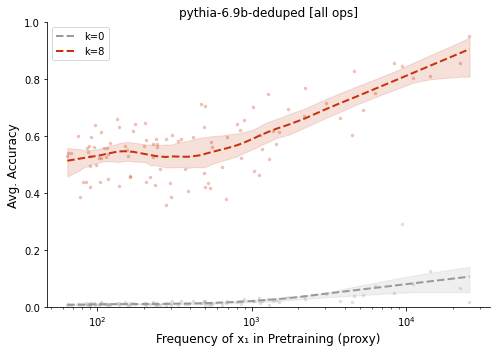

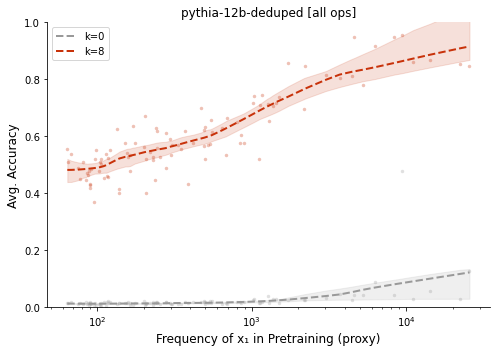

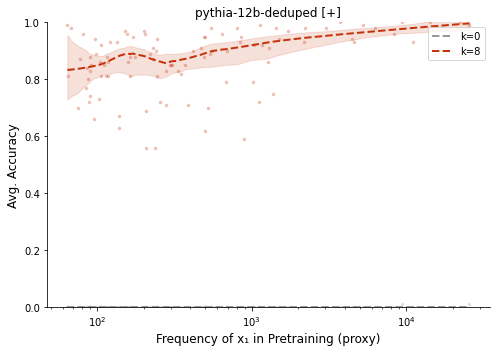

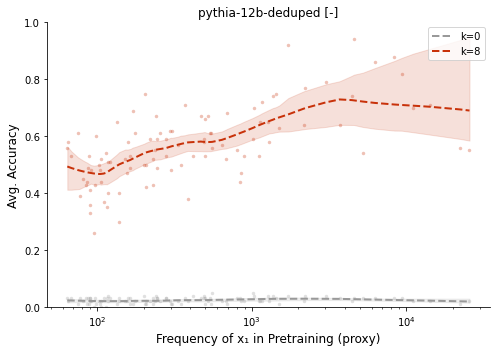

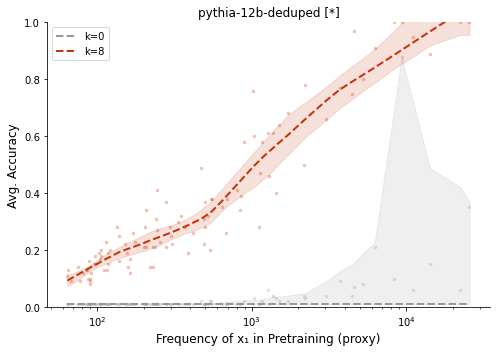

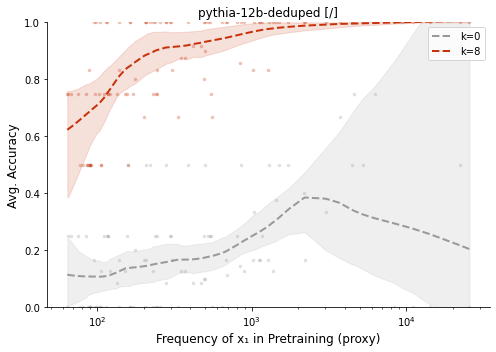

In [5]:
results = pd.read_csv("pythia_fewshot_results.csv")

# ── 6. PLOT: FIGURE 1 STYLE (per model, per k) ───────────────────────────────

def pythia_size_m(name):
    m = re.search(r"pythia-(\d+(?:\.\d+)?)(m|b)", name.lower())
    if not m: return float("inf")
    val = float(m.group(1))
    return val if m.group(2) == "m" else val * 1000

models_sorted = sorted(results["model"].unique(), key=pythia_size_m)
# k_colors = {0: "#999999", 2: "#E6A020", 8: "#C8320A"}
k_colors = {0: "#999999", 8: "#C8320A"}

def plot_freq_vs_acc(results, model_name, op=None):
    """
    Replicate Figure 1: x-axis = freq_a (proxy for Pile frequency),
    y-axis = avg accuracy for that x1 value, one curve per k.
    """
    d = results[results["model"] == model_name].copy()
    if op:
        d = d[d["op"] == op]
    
    fig, ax = plt.subplots(figsize=(7, 5))
    
    for k in K_VALUES:
        dk = d[d["k"] == k]
        
        # Average accuracy per x1 value (averaged over all x2)
        per_x1 = (
            dk.groupby("a")
              .agg(freq=("freq_a", "first"),
                   acc=("is_correct", "mean"))
              .reset_index()
        )
        
        x = per_x1["freq"].to_numpy(dtype=float)
        y = per_x1["acc"].to_numpy(dtype=float)
        
        # LOWESS
        log_x = np.log10(x + 1)
        order = np.argsort(log_x)
        lx_s, y_s = log_x[order], y[order]
        lowess = sm.nonparametric.lowess(y_s, lx_s, frac=0.4, return_sorted=True)
        lx_sm, y_sm = lowess[:, 0], lowess[:, 1]
        
        # Bootstrap CI
        rng = np.random.default_rng(42)
        boots = []
        for _ in range(200):
            idx = rng.integers(0, len(lx_s), len(lx_s))
            b = sm.nonparametric.lowess(y_s[idx], lx_s[idx], frac=0.4, return_sorted=True)
            boots.append(np.interp(lx_sm, b[:, 0], b[:, 1]))
        ci_lo = np.percentile(boots, 2.5, axis=0)
        ci_hi = np.percentile(boots, 97.5, axis=0)
        
        color = k_colors[k]
        ax.scatter(10**lx_s, y_s, color=color, alpha=0.3, s=12, linewidths=0)
        ax.plot(10**lx_sm, y_sm, color=color, linewidth=2,
                linestyle="--", label=f"k={k}")
        ax.fill_between(10**lx_sm, ci_lo, ci_hi, color=color, alpha=0.15)
    
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frequency of x₁ in Pretraining (proxy)", fontsize=12)
    ax.set_ylabel("Avg. Accuracy", fontsize=12)
    op_str = f" [{op}]" if op else " [all ops]"
    ax.set_title(f"{model_name.split('/')[-1]}{op_str}", fontsize=12)
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    return fig

# Plot for each model, all ops combined
for mn in models_sorted:
    plot_freq_vs_acc(results, mn)

# Or per operator for the largest model:
for op in OPS:
    plot_freq_vs_acc(results, "EleutherAI/pythia-12b-deduped", op=op)

## By Frequency of x2

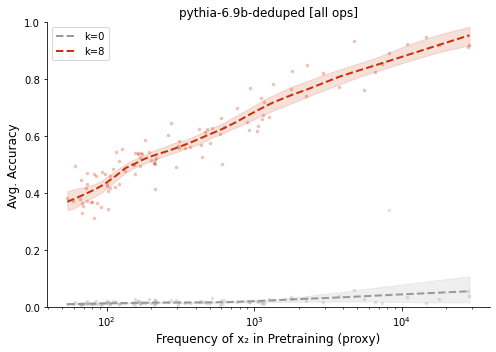

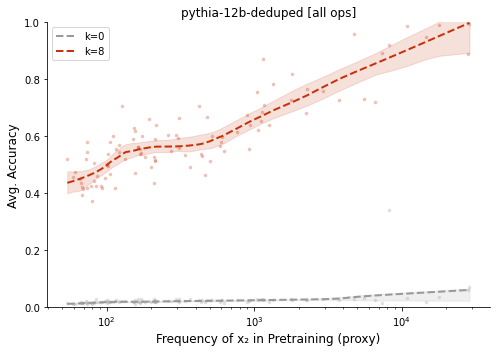

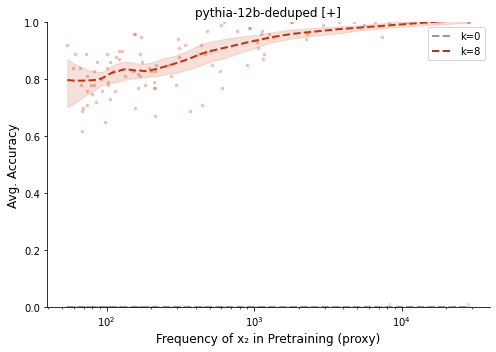

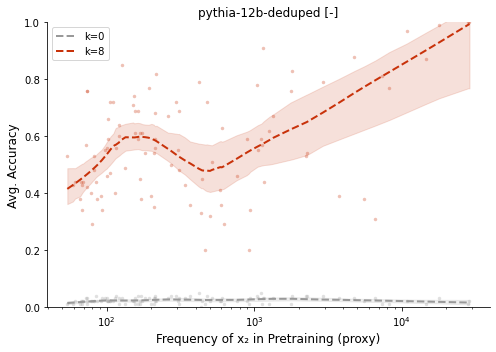

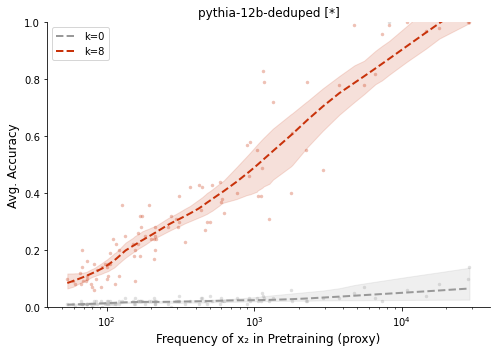

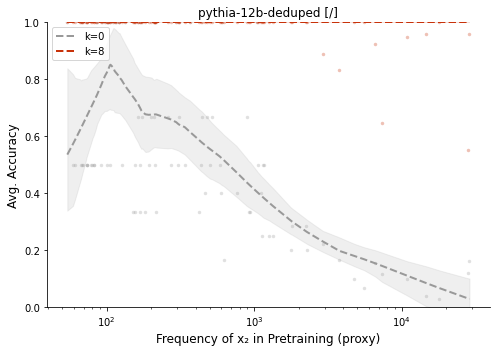

In [24]:
results = pd.read_csv("pythia_fewshot_results.csv")

# ── 6. PLOT: FIGURE 1 STYLE (per model, per k) ───────────────────────────────

from collections import Counter
import pandas as pd
import json

# load your raw arithmetic matches file again
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

raw = load_jsonl("./pile_arith_matches_full_fresh_deduped.jsonl")

# build frequency of x2 / b
freq_b = Counter()
for r in raw:
    freq_b[int(r["b"])] += 1

# make sure b types match
results["b"] = results["b"].astype(int)

# attach freq_b to results
results["freq_b"] = results["b"].map(freq_b)

def pythia_size_m(name):
    m = re.search(r"pythia-(\d+(?:\.\d+)?)(m|b)", name.lower())
    if not m:
        return float("inf")
    val = float(m.group(1))
    return val if m.group(2) == "m" else val * 1000

models_sorted = sorted(results["model"].unique(), key=pythia_size_m)
k_colors = {0: "#999999", 8: "#C8320A"}

def plot_freq_vs_acc_x2(results, model_name, op=None):
    """
    x-axis = freq of x2 in pretraining (proxy),
    y-axis = avg accuracy for that x2 value, one curve per k.
    """
    d = results[results["model"] == model_name].copy()
    if op:
        d = d[d["op"] == op]

    fig, ax = plt.subplots(figsize=(7, 5))

    for k in K_VALUES:
        dk = d[d["k"] == k]

        # Average accuracy per x2 value (averaged over all x1)
        per_x2 = (
            dk.groupby("b")
              .agg(freq=("freq_b", "first"),
                   acc=("is_correct", "mean"))
              .reset_index()
        )

        x = per_x2["freq"].to_numpy(dtype=float)
        y = per_x2["acc"].to_numpy(dtype=float)

        # LOWESS
        log_x = np.log10(x + 1)
        order = np.argsort(log_x)
        lx_s, y_s = log_x[order], y[order]
        lowess = sm.nonparametric.lowess(y_s, lx_s, frac=0.4, return_sorted=True)
        lx_sm, y_sm = lowess[:, 0], lowess[:, 1]

        # Bootstrap CI
        rng = np.random.default_rng(42)
        boots = []
        for _ in range(200):
            idx = rng.integers(0, len(lx_s), len(lx_s))
            bfit = sm.nonparametric.lowess(
                y_s[idx], lx_s[idx], frac=0.4, return_sorted=True
            )
            boots.append(np.interp(lx_sm, bfit[:, 0], bfit[:, 1]))
        ci_lo = np.percentile(boots, 2.5, axis=0)
        ci_hi = np.percentile(boots, 97.5, axis=0)

        color = k_colors[k]
        ax.scatter(10**lx_s, y_s, color=color, alpha=0.3, s=12, linewidths=0)
        ax.plot(10**lx_sm, y_sm, color=color, linewidth=2,
                linestyle="--", label=f"k={k}")
        ax.fill_between(10**lx_sm, ci_lo, ci_hi, color=color, alpha=0.15)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frequency of x₂ in Pretraining (proxy)", fontsize=12)
    ax.set_ylabel("Avg. Accuracy", fontsize=12)
    op_str = f" [{op}]" if op else " [all ops]"
    ax.set_title(f"{model_name.split('/')[-1]}{op_str}", fontsize=12)
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    return fig

# Plot for each model, all ops combined
for mn in models_sorted:
    plot_freq_vs_acc_x2(results, mn)

# Or per operator for the largest model
for op in OPS:
    plot_freq_vs_acc_x2(results, "EleutherAI/pythia-12b-deduped", op=op)

## By frequency of whole prompt

/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


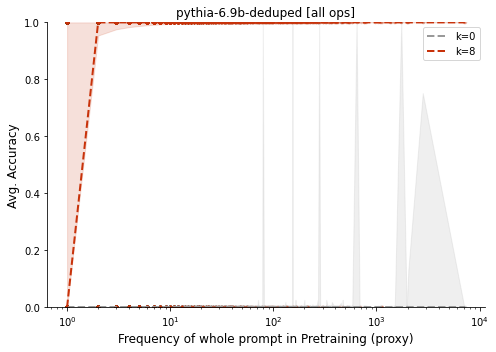

/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


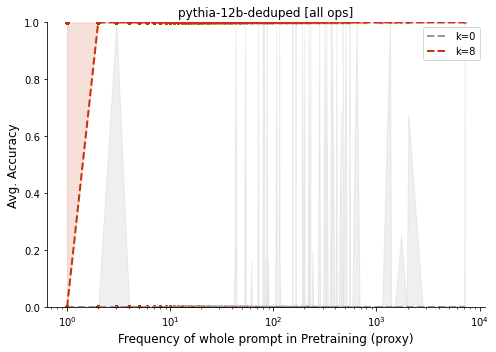

/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


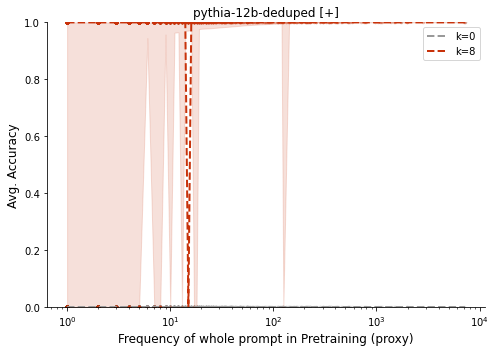

/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


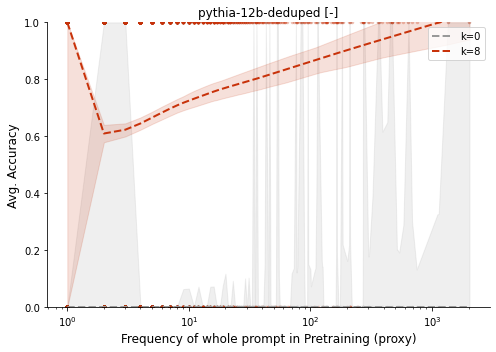

/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


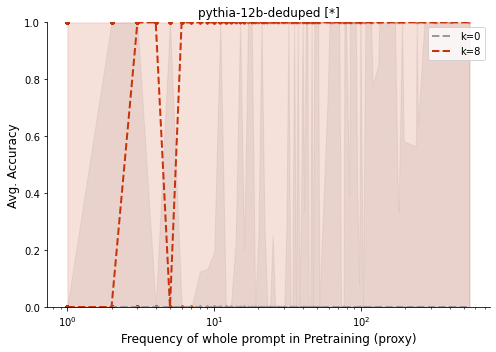

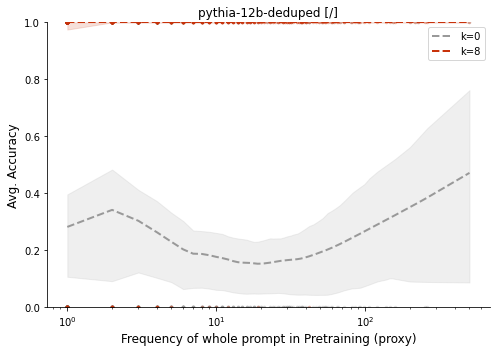

In [27]:
from collections import Counter
import json
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import re

results = pd.read_csv("pythia_fewshot_results.csv")

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

raw = load_jsonl("./pile_arith_matches_full_fresh_deduped.jsonl")

# Count frequency of the whole expression (a op b = c) in the raw corpus
freq_expr = Counter()
for r in raw:
    key = (int(r["a"]), str(r["op"]), int(r["b"]), int(r["c"]))
    freq_expr[key] += 1

# Build same key in results
results["a"] = results["a"].astype(int)
results["b"] = results["b"].astype(int)
results["c"] = results["c"].astype(int)
results["expr_key"] = list(zip(results["a"], results["op"], results["b"], results["c"]))

# Map full-prompt frequency onto results
results["freq_expr"] = results["expr_key"].map(freq_expr)

def pythia_size_m(name):
    m = re.search(r"pythia-(\d+(?:\.\d+)?)(m|b)", name.lower())
    if not m:
        return float("inf")
    val = float(m.group(1))
    return val if m.group(2) == "m" else val * 1000

models_sorted = sorted(results["model"].unique(), key=pythia_size_m)
k_colors = {0: "#999999", 8: "#C8320A"}

def plot_promptfreq_vs_acc(results, model_name, op=None):
    """
    x-axis = frequency of whole prompt (a op b = c) in pretraining proxy
    y-axis = avg accuracy for that prompt, one curve per k
    """
    d = results[results["model"] == model_name].copy()
    if op:
        d = d[d["op"] == op]

    fig, ax = plt.subplots(figsize=(7, 5))

    for k in K_VALUES:
        dk = d[d["k"] == k].copy()

        per_expr = (
            dk.groupby("expr_key")
              .agg(freq=("freq_expr", "first"),
                   acc=("is_correct", "mean"))
              .reset_index()
        )

        # optional: drop prompts not found in raw corpus
        per_expr = per_expr.dropna(subset=["freq"])

        x = per_expr["freq"].to_numpy(dtype=float)
        y = per_expr["acc"].to_numpy(dtype=float)

        log_x = np.log10(x + 1)
        order = np.argsort(log_x)
        lx_s, y_s = log_x[order], y[order]

        lowess = sm.nonparametric.lowess(y_s, lx_s, frac=0.4, return_sorted=True)
        lx_sm, y_sm = lowess[:, 0], lowess[:, 1]

        rng = np.random.default_rng(42)
        boots = []
        for _ in range(200):
            idx = rng.integers(0, len(lx_s), len(lx_s))
            bfit = sm.nonparametric.lowess(
                y_s[idx], lx_s[idx], frac=0.4, return_sorted=True
            )
            boots.append(np.interp(lx_sm, bfit[:, 0], bfit[:, 1]))

        ci_lo = np.percentile(boots, 2.5, axis=0)
        ci_hi = np.percentile(boots, 97.5, axis=0)

        color = k_colors[k]
        ax.scatter(10**lx_s, y_s, color=color, alpha=0.3, s=12, linewidths=0)
        ax.plot(10**lx_sm, y_sm, color=color, linewidth=2,
                linestyle="--", label=f"k={k}")
        ax.fill_between(10**lx_sm, ci_lo, ci_hi, color=color, alpha=0.15)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frequency of whole prompt in Pretraining (proxy)", fontsize=12)
    ax.set_ylabel("Avg. Accuracy", fontsize=12)
    op_str = f" [{op}]" if op else " [all ops]"
    ax.set_title(f"{model_name.split('/')[-1]}{op_str}", fontsize=12)
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    return fig

for mn in models_sorted:
    plot_promptfreq_vs_acc(results, mn)

for op in OPS:
    plot_promptfreq_vs_acc(results, "EleutherAI/pythia-12b-deduped", op=op)

In [28]:
dk = results[(results["model"] == "EleutherAI/pythia-12b-deduped") & (results["k"] == 8)].copy()

per_expr = (
    dk.groupby("expr_key")
      .agg(freq=("freq_expr", "first"),
           acc=("is_correct", "mean"),
           n=("is_correct", "size"))
      .reset_index()
)

print(per_expr["n"].describe())
print(per_expr["acc"].value_counts().head(10))
print(per_expr["freq"].describe())
print(per_expr["freq"].value_counts().head(20))

count    30572.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: n, dtype: float64
1.0    18354
0.0    12218
Name: acc, dtype: int64
count    30572.000000
mean         4.324545
std         71.831807
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       7196.000000
Name: freq, dtype: float64
0     21031
1      4167
2      1613
3       822
4       528
5       345
6       261
7       180
9       152
8       138
10      105
11       99
12       77
14       64
15       59
13       57
18       45
16       41
17       41
21       32
Name: freq, dtype: int64


In [26]:
per_x2 = (
    dk.groupby("b")
      .agg(freq=("freq_b", "first"),
           acc=("is_correct", "mean"),
           n=("is_correct", "size"))
      .reset_index()
)

print(per_x2["n"].describe())
print(per_x2["acc"].describe())

count    100.000000
mean     305.720000
std       11.661973
min      300.000000
25%      302.000000
50%      302.000000
75%      304.000000
max      400.000000
Name: n, dtype: float64
count    100.000000
mean       0.597395
std        0.145531
min        0.374172
25%        0.502483
50%        0.561985
75%        0.665839
max        0.994286
Name: acc, dtype: float64


In [19]:
results

,a,op,b,c,freq_a,log_freq_a,prompt,pred,gen_suffix,is_correct,k,model,model_acc_overall,expr_key,freq_expr
0,0,+,0,0,9343,3.970533,0 + 0 =,0.0,"0.\n-1, 0,",True,0,EleutherAI/pythia-6.9b-deduped,0.020934,"(0, +, 0, 0)",1737
1,0,+,1,1,9343,3.970533,0 + 1 =,0.0,"0.\n-1, 1\n",False,0,EleutherAI/pythia-6.9b-deduped,0.020934,"(0, +, 1, 1)",1387
2,0,+,2,2,9343,3.970533,0 + 2 =,0.0,0. Let s = -0.,False,0,EleutherAI/pythia-6.9b-deduped,0.020934,"(0, +, 2, 2)",576
3,0,+,3,3,9343,3.970533,0 + 3 =,0.0,0. Let s = -1 +,False,0,EleutherAI/pythia-6.9b-deduped,0.020934,"(0, +, 3, 3)",399
4,0,+,4,4,9343,3.970533,0 + 4 =,0.0,0. Let s = -0.,False,0,EleutherAI/pythia-6.9b-deduped,0.020934,"(0, +, 4, 4)",336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122283,99,/,3,33,202,2.307496,48 / 2 = 24\n40 / 10 = 4\n28 / 14 = 2\n47 / 47...,33.0,33\n\nA:\n\nI,True,8,EleutherAI/pythia-12b-deduped,0.600353,"(99, /, 3, 33)",3
122284,99,/,9,11,202,2.307496,48 / 2 = 24\n40 / 10 = 4\n28 / 14 = 2\n47 / 47...,11.0,11\n\nA:\n\nI,True,8,EleutherAI/pythia-12b-deduped,0.600353,"(99, /, 9, 11)",2
122285,99,/,11,9,202,2.307496,48 / 2 = 24\n40 / 10 = 4\n28 / 14 = 2\n47 / 47...,9.0,9\n\nA:\n\nI,True,8,EleutherAI/pythia-12b-deduped,0.600353,"(99, /, 11, 9)",0
122286,99,/,33,3,202,2.307496,48 / 2 = 24\n40 / 10 = 4\n28 / 14 = 2\n47 / 47...,3.0,3\n\nA:\n\nI,True,8,EleutherAI/pythia-12b-deduped,0.600353,"(99, /, 33, 3)",0


In [17]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm.auto import tqdm

INT_RE = re.compile(r"^\s*([+-]?\d+)")

def safe_int_from_text(s):
    m = INT_RE.match(s)
    return int(m.group(1)) if m else None


@torch.inference_mode()
def eval_greedy_fewshot(model, tokenizer, df_eval, k=8, batch_size=16,
                        max_new_tokens=8, seed=42):
    """
    Evaluate model on df_eval with k-shot prompts.
    Returns accuracy and dataframe with predictions.
    """
    records = df_eval.to_dict("records")

    prompts = [
        build_few_shot_prompt(r["a"], r["op"], r["b"], k=k, seed=seed)
        for r in records
    ]
    targets = [r["c"] for r in records]

    out_rows = []
    correct = 0

    # strongly recommended for decoder-only models
    tokenizer.padding_side = "left"
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    for i in tqdm(range(0, len(prompts), batch_size), desc=f"k={k}"):
        batch_prompts = prompts[i:i+batch_size]
        batch_targets = targets[i:i+batch_size]
        batch_records = records[i:i+batch_size]

        enc = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        )
        enc = {kk: vv.to(model.device) for kk, vv in enc.items()}

        gen = model.generate(
            **enc,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

        prompt_lens = enc["attention_mask"].sum(dim=1).tolist()

        for bp, tgt, seq, rec, plen in zip(batch_prompts, batch_targets, gen, batch_records, prompt_lens):
            suffix_ids = seq[int(plen):]
            suffix_txt = tokenizer.decode(suffix_ids, skip_special_tokens=True)
            pred = safe_int_from_text(suffix_txt)
            is_correct = (pred == tgt)
            correct += int(is_correct)

            out_rows.append({
                **rec,
                "prompt": bp,
                "pred": pred,
                "gen_suffix": suffix_txt[:40],
                "is_correct": is_correct,
                "k": k,
            })

    acc = correct / max(1, len(prompts))
    return acc, pd.DataFrame(out_rows)


def scatter_freq_vs_acc(df, model_name=None, freq_col="freq_prompt", figsize=(8, 6), k=None):
    """
    Scatter plot of pretraining frequency vs. per-prompt accuracy.
    """
    d = df.copy()

    if model_name is not None:
        d = d[d["model"] == model_name]

    if k is not None and "k" in d.columns:
        d = d[d["k"] == k]

    per_prompt = (
        d.groupby("prompt")
         .agg(
             freq=(freq_col, "first"),
             acc=("is_correct", "mean"),
             n=("is_correct", "count"),
         )
         .reset_index()
    )

    x = per_prompt["freq"].to_numpy(dtype=float)
    y = per_prompt["acc"].to_numpy(dtype=float)

    log_x = np.log10(x)
    order = np.argsort(log_x)
    lx_sorted = log_x[order]
    y_sorted = y[order]

    lowess = sm.nonparametric.lowess(y_sorted, lx_sorted, frac=0.4, return_sorted=True)
    lx_smooth, y_smooth = lowess[:, 0], lowess[:, 1]

    n_boot = 200
    boot_curves = []
    rng = np.random.default_rng(42)

    for _ in range(n_boot):
        idx = rng.integers(0, len(lx_sorted), len(lx_sorted))
        b = sm.nonparametric.lowess(y_sorted[idx], lx_sorted[idx], frac=0.4, return_sorted=True)
        boot_curves.append(np.interp(lx_smooth, b[:, 0], b[:, 1]))

    boot_curves = np.array(boot_curves)
    ci_lo = np.percentile(boot_curves, 2.5, axis=0)
    ci_hi = np.percentile(boot_curves, 97.5, axis=0)

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(x, y, color="#C8860A", alpha=0.55, s=18, linewidths=0, zorder=2)

    smooth_x = 10 ** lx_smooth
    ax.plot(smooth_x, y_smooth, color="#C8860A", linewidth=2, linestyle="--", zorder=3)
    # ax.fill_between(smooth_x, ci_lo, ci_hi, color="#C8860A", alpha=0.18, zorder=1)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frequency in Pretraining", fontsize=13)
    ax.set_ylabel("Avg. Accuracy of a Number", fontsize=13)

    title = model_name if model_name else "All models (averaged)"
    if k is not None:
        title += f" | {k}-shot"

    ax.set_title(title, fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig

In [13]:
all_results = []

for name in MODEL_NAMES:
    print("\n=== ", name, " ===")

    model = AutoModelForCausalLM.from_pretrained(
        name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    model.eval()

    acc, df_pred = eval_greedy_fewshot(
        model,
        tokenizer,
        df_eval,
        k=8,                 # <-- 8-shot prompting
        batch_size=16,
        max_new_tokens=8,
        seed=42
    )
    print("accuracy:", acc)

    df = df_pred.copy()
    df["model"] = name
    df["model_acc_overall"] = acc
    all_results.append(df)

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

results_8shot = pd.concat(all_results, ignore_index=True)
results_8shot.to_csv("pythia_freq_results_8shot.csv", index=False)
results_8shot.head()


===  EleutherAI/pythia-6.9b-deduped  ===


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

k=8:   0%|          | 0/625 [00:00<?, ?it/s]

accuracy: 0.0234

===  EleutherAI/pythia-12b-deduped  ===


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

k=8:   0%|          | 0/625 [00:00<?, ?it/s]

accuracy: 0.027


,row_index,a,op,b,c,prompt,freq_a,freq_b,freq_c,freq_prompt,log_freq_a,log_freq_b,log_freq_c,log_freq_prompt,pred,gen_suffix,is_correct,k,model,model_acc_overall
0,87278154,8088,/,8,1011,37 / 71 = None\n66 / 72 = None\n72 / 61 = None...,1,6642,21,1,0.301030,3.822364,1.342423,0.301030,8088.0,\n8088 / 8 = None\n8 / 80 = None\n,False,8,EleutherAI/pythia-6.9b-deduped,0.0234
1,86916567,10316,+,1084,11400,37 + 71 = 108\n66 + 72 = 138\n72 + 61 = 133\n7...,1,1,1,1,0.301030,0.301030,0.301030,0.301030,16.0,16 + 1084 = 1240\n10 + 12 = 22,False,8,EleutherAI/pythia-6.9b-deduped,0.0234
2,134111686,9,-,7,2,37 - 72 = -35\n66 - 73 = -7\n72 - 62 = 10\n7 -...,3708,5566,15071,93,3.569257,3.745621,4.178171,1.973128,NaN,= -2\n-1 - -1,False,8,EleutherAI/pythia-6.9b-deduped,0.0234
3,89510679,115,-,5,110,37 - 71 = -34\n66 - 72 = -6\n72 - 61 = 11\n7 -...,61,10853,200,1,1.792392,4.035590,2.303196,0.301030,NaN,= 110\n79 - 5 = 74\n,False,8,EleutherAI/pythia-6.9b-deduped,0.0234
4,74267756,521,-,31,490,37 - 71 = -34\n66 - 72 = -6\n72 - 61 = 11\n7 -...,4,303,32,1,0.698970,2.482874,1.518514,0.301030,NaN,= -520\n-521 = -520,False,8,EleutherAI/pythia-6.9b-deduped,0.0234


/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


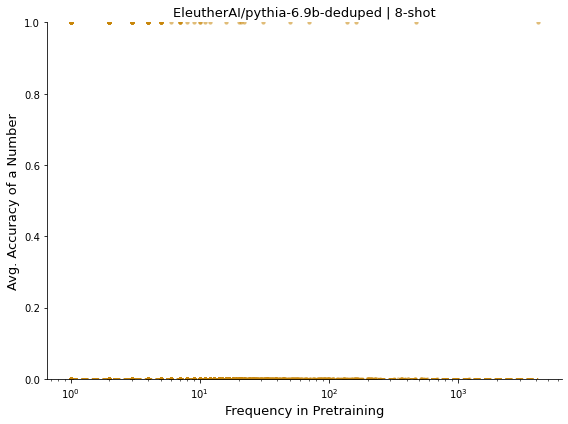

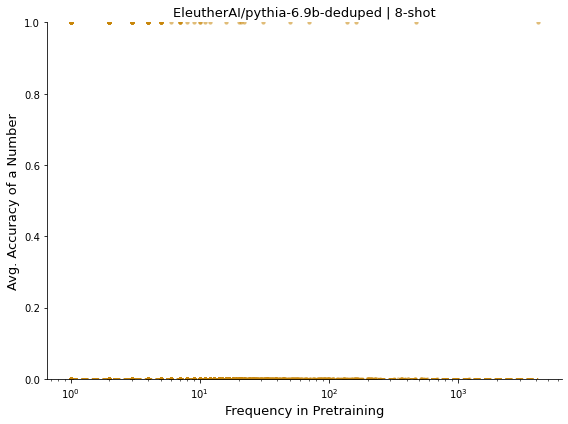

In [16]:
scatter_freq_vs_acc(results_8shot, model_name="EleutherAI/pythia-6.9b-deduped", k=8)

# or averaged across all models
# scatter_freq_vs_acc(results_8shot, k=8)

/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


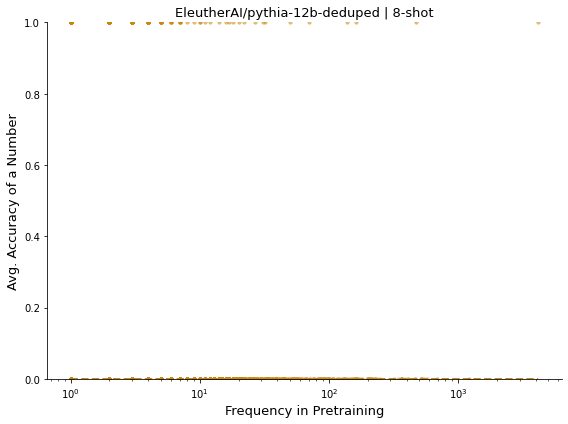

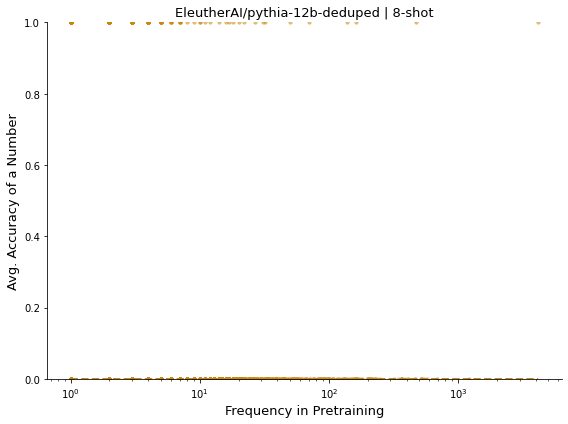

In [19]:
scatter_freq_vs_acc(results_8shot, model_name="EleutherAI/pythia-12b-deduped", k=8)

# or averaged across all models
# scatter_freq_vs_acc(results_8shot, k=8)

/usr/local/pace-apps/manual/packages/anaconda3/2022.05.0.1/lib/python3.9/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in true_divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


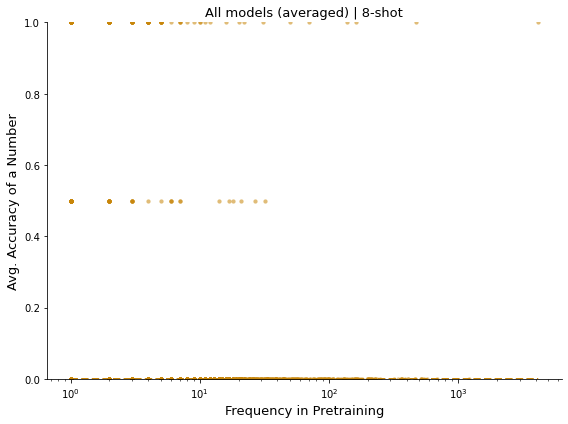

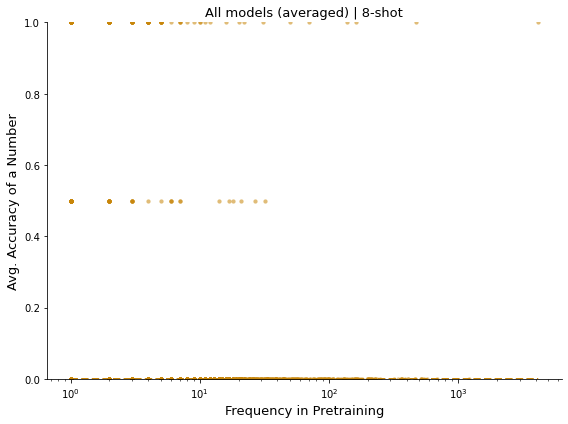

In [18]:
scatter_freq_vs_acc(results_8shot, k=8)

# Log-Prob

## Sample prompts from corpus, no limits, 0-shot

In [31]:
@torch.inference_mode()
def eval_greedy(model, tokenizer, df_eval, batch_size=32):
    prompts = (df_eval["prompt"] + " ").tolist()
    targets = df_eval["c"].astype(str).tolist()

    pad_id = tokenizer.pad_token_id
    if pad_id is None:
        if tokenizer.eos_token_id is None:
            raise ValueError("Tokenizer needs either pad_token_id or eos_token_id.")
        pad_id = tokenizer.eos_token_id

    out_rows = []
    total_logprob_sum = 0.0
    total_target_tokens = 0

    for i in tqdm(range(0, len(prompts), batch_size), desc="logprob"):
        batch_prompts = prompts[i:i+batch_size]
        batch_targets = targets[i:i+batch_size]

        p_enc = tokenizer(batch_prompts, add_special_tokens=False)
        t_enc = tokenizer(batch_targets, add_special_tokens=False)

        batch_input_ids = []
        batch_attention_mask = []
        prompt_lens = []
        target_lens = []

        for p_ids, t_ids in zip(p_enc["input_ids"], t_enc["input_ids"]):
            ids = p_ids + t_ids
            mask = [1] * len(ids)

            batch_input_ids.append(ids)
            batch_attention_mask.append(mask)
            prompt_lens.append(len(p_ids))
            target_lens.append(len(t_ids))

        max_len = max(len(x) for x in batch_input_ids)

        padded_ids = []
        padded_mask = []
        for ids, mask in zip(batch_input_ids, batch_attention_mask):
            pad_len = max_len - len(ids)
            padded_ids.append(ids + [pad_id] * pad_len)
            padded_mask.append(mask + [0] * pad_len)

        input_ids = torch.tensor(padded_ids, device=model.device)
        attention_mask = torch.tensor(padded_mask, device=model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
        next_token_ids = input_ids[:, 1:]

        token_logprobs = log_probs.gather(
            dim=2,
            index=next_token_ids.unsqueeze(-1)
        ).squeeze(-1)

        for bp, tgt, p_len, t_len, tlp in zip(
            batch_prompts, batch_targets, prompt_lens, target_lens, token_logprobs
        ):
            start = p_len - 1
            end = start + t_len
            tgt_token_lps = tlp[start:end]

            target_logprob = tgt_token_lps.sum().item()
            avg_target_logprob = tgt_token_lps.mean().item()

            total_logprob_sum += target_logprob
            total_target_tokens += t_len

            out_rows.append({
                "prompt": bp.strip(),
                "target": tgt,
                "target_text": tgt,
                "target_num_tokens": t_len,
                "target_logprob": target_logprob,
                "avg_target_logprob": avg_target_logprob,
            })

    mean_logprob_per_example = total_logprob_sum / max(1, len(prompts))
    mean_logprob_per_token = total_logprob_sum / max(1, total_target_tokens)

    return mean_logprob_per_example, mean_logprob_per_token, pd.DataFrame(out_rows)

In [ ]:
all_results = []

for name in MODEL_NAMES:
    print("\n=== ", name, " ===")

    model = AutoModelForCausalLM.from_pretrained(
        name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    model.eval()

    mean_lp_ex, mean_lp_tok, df_pred = eval_greedy(
        model, tokenizer, df_eval, batch_size=32
    )
    print("mean logprob / example:", mean_lp_ex)
    print("mean logprob / token:", mean_lp_tok)

    # merge model outputs with per-example frequency features
    df = df_eval.merge(df_pred, on="prompt", how="left")
    df["model"] = name
    df["mean_logprob_per_example"] = mean_lp_ex
    df["mean_logprob_per_token"] = mean_lp_tok
    all_results.append(df)

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

results = pd.concat(all_results, ignore_index=True)
results.to_csv("pythia_freq_results_logprob.csv", index=False)
results.head()


===  EleutherAI/pythia-70m-deduped  ===


logprob:   0%|          | 0/313 [00:00<?, ?it/s]

mean logprob / example: -11.35965703125
mean logprob / token: -7.47345857319079

===  EleutherAI/pythia-160m-deduped  ===


logprob:   0%|          | 0/313 [00:00<?, ?it/s]

mean logprob / example: -13.614696484375
mean logprob / token: -8.957037160773027

===  EleutherAI/pythia-410m-deduped  ===


...

logprob:   0%|          | 0/313 [00:00<?, ?it/s]

mean logprob / example: -12.41468046875
mean logprob / token: -8.167552939967106

===  EleutherAI/pythia-2.8b-deduped  ===


logprob:   0%|          | 0/313 [00:00<?, ?it/s]

mean logprob / example: -15.185553515625
mean logprob / token: -9.990495733963815

===  EleutherAI/pythia-6.9b-deduped  ===


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [35]:
results

,row_index,a,op,b,c,prompt,freq_a,freq_b,freq_c,freq_prompt,...,log_freq_c,log_freq_prompt,target,target_text,target_num_tokens,target_logprob,avg_target_logprob,model,mean_logprob_per_example,mean_logprob_per_token
0,87278154,8088,/,8,1011,8088 / 8 =,1,6642,21,1,...,1.342423,0.301030,1011,1011,2,-12.750000,-6.375000,EleutherAI/pythia-70m-deduped,-11.359657,-7.473459
1,86916567,10316,+,1084,11400,10316 + 1084 =,1,1,1,1,...,0.301030,0.301030,11400,11400,2,-14.531250,-7.265625,EleutherAI/pythia-70m-deduped,-11.359657,-7.473459
2,134111686,9,-,7,2,9 - 7 =,3708,5566,15071,93,...,4.178171,1.973128,2,2,1,-5.546875,-5.546875,EleutherAI/pythia-70m-deduped,-11.359657,-7.473459
3,89510679,115,-,5,110,115 - 5 =,61,10853,200,1,...,2.303196,0.301030,110,110,1,-8.367188,-8.367188,EleutherAI/pythia-70m-deduped,-11.359657,-7.473459
4,74267756,521,-,31,490,521 - 31 =,4,303,32,1,...,1.518514,0.301030,490,490,1,-10.554688,-10.554688,EleutherAI/pythia-70m-deduped,-11.359657,-7.473459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,33491792,136,-,140,-4,136 - 140 =,50,78,2724,1,...,3.435367,0.301030,-4,-4,2,-10.046875,-5.023438,EleutherAI/pythia-12b-deduped,-12.251202,-8.060001
79996,109355595,524288,+,393216,917504,524288 + 393216 =,14,11,4,2,...,0.698970,0.477121,917504,917504,3,-15.421875,-5.140625,EleutherAI/pythia-12b-deduped,-12.251202,-8.060001
79997,60801910,2400,+,1620,4020,2400 + 1620 =,55,4,3,1,...,0.602060,0.301030,4020,4020,2,-10.695312,-5.347656,EleutherAI/pythia-12b-deduped,-12.251202,-8.060001
79998,77781491,5050,-,5048,2,5050 - 5048 =,10,1,15071,1,...,4.178171,0.301030,2,2,1,-6.601562,-6.601562,EleutherAI/pythia-12b-deduped,-12.251202,-8.060001


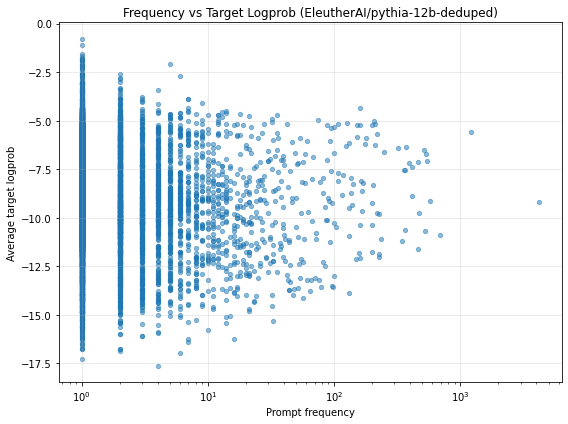

,prompt,freq_prompt,avg_target_logprob
0,-1 * -3 =,1,-10.195312
1,-1 * -5 =,1,-9.617188
2,-1 * 2 =,5,-7.636719
3,-1 * 7 =,1,-8.390625
4,-1 * 8 =,1,-8.398438
...,...,...,...
9995,999999999 * 999999999 =,1,-3.431641
9996,999999999 + 999999999 =,2,-5.136719
9997,9999999999 + 1 =,4,-4.437500
9998,9999999999999 * 9999999999999 =,1,-3.544922


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def scatter_freq_vs_logprob(df, model_name=None, freq_col="freq_prompt", figsize=(8, 6)):
    """
    Scatter plot of pretraining frequency vs. target logprob.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns:
        - prompt
        - freq_col
        - avg_target_logprob
        - model (optional, if using model_name)
    model_name : str or None
        If provided, filters to that model only.
    freq_col : str
        Frequency column to plot on x-axis.
    figsize : tuple
        Figure size.
    """
    d = df.copy()

    if model_name is not None:
        d = d[d["model"] == model_name].copy()

    # one row per prompt
    per_prompt = (
        d.groupby("prompt", as_index=False)
         .agg({
             freq_col: "first",
             "avg_target_logprob": "mean"
         })
    )

    # remove invalid rows
    per_prompt = per_prompt.replace([np.inf, -np.inf], np.nan)
    per_prompt = per_prompt.dropna(subset=[freq_col, "avg_target_logprob"])
    per_prompt = per_prompt[per_prompt[freq_col] > 0]

    plt.figure(figsize=figsize)
    plt.scatter(
        per_prompt[freq_col],
        per_prompt["avg_target_logprob"],
        alpha=0.5,
        s=18,
    )
    plt.xscale("log")
    plt.xlabel("Prompt frequency")
    plt.ylabel("Average target logprob")
    plt.title(
        f"Frequency vs Target Logprob"
        + (f" ({model_name})" if model_name is not None else "")
    )
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return per_prompt

scatter_freq_vs_logprob(results, model_name="EleutherAI/pythia-12b-deduped")

## k-shot, only 0-99 x 0-99
- generate examples 

In [10]:
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer


def generate_arithmetic_dataset(max_n=99, include_division=True, integer_only_division=True):
    """
    Generate all arithmetic examples for a,b in [0, max_n].

    Prompts look like:
        '3 + 4 ='
    Targets look like:
        '7'

    Assumptions:
    - +, -, * always included
    - division:
        * skip b == 0
        * if integer_only_division=True, keep only exact divisions
    """
    rows = []
    example_id = 0

    ops = ["+", "-", "*"]
    if include_division:
        ops.append("/")

    for a in range(max_n + 1):
        for b in range(max_n + 1):
            for op in ops:
                if op == "+":
                    c = str(a + b)

                elif op == "-":
                    c = str(a - b)

                elif op == "*":
                    c = str(a * b)

                elif op == "/":
                    if b == 0:
                        continue
                    if integer_only_division and a % b != 0:
                        continue
                    if integer_only_division:
                        c = str(a // b)
                    else:
                        # alternative formatting if you want all nonzero divisions
                        c = str(a / b)

                rows.append({
                    "example_id": example_id,
                    "a": a,
                    "b": b,
                    "op": op,
                    "prompt": f"{a} {op} {b} =",
                    "c": c,
                })
                example_id += 1

    return pd.DataFrame(rows)


def build_shared_kshot_prefix(k=8):
    """
    Returns ONE shared k-shot prefix used for all eval examples.

    These are fixed solved examples, chosen to cover different ops.
    Keep formatting consistent with the eval prompts.
    """
    demos = [
        ("2 + 3 =", "5"),
        ("9 - 4 =", "5"),
        ("6 * 7 =", "42"),
        ("8 / 2 =", "4"),
        ("15 + 27 =", "42"),
        ("50 - 19 =", "31"),
        ("12 * 8 =", "96"),
        ("81 / 9 =", "9"),
    ]

    if k > len(demos):
        raise ValueError(f"Requested k={k}, but only {len(demos)} fixed demos are defined.")

    selected = demos[:k]
    prefix = "\n".join([f"{q} {ans}" for q, ans in selected])
    return prefix


def add_shared_kshot_prompt(df, k_shot=0):
    """
    If k_shot=0:
        eval_prompt = prompt

    If k_shot>0:
        eval_prompt = shared_prefix + '\\n' + prompt
    """
    df = df.copy()

    if k_shot == 0:
        df["eval_prompt"] = df["prompt"]
    else:
        prefix = build_shared_kshot_prefix(k=k_shot)
        df["eval_prompt"] = prefix + "\n" + df["prompt"]

    return df


@torch.inference_mode()
def eval_greedy(model, tokenizer, df_eval, batch_size=32):
    prompts = df_eval["eval_prompt"].astype(str).tolist()
    targets = df_eval["c"].astype(str).tolist()
    example_ids = df_eval["example_id"].tolist()

    pad_id = tokenizer.pad_token_id
    if pad_id is None:
        if tokenizer.eos_token_id is None:
            raise ValueError("Tokenizer needs either pad_token_id or eos_token_id.")
        pad_id = tokenizer.eos_token_id

    model_device = next(model.parameters()).device

    out_rows = []
    total_logprob_sum = 0.0
    total_target_tokens = 0

    for i in tqdm(range(0, len(prompts), batch_size), desc="logprob"):
        batch_prompts = prompts[i:i+batch_size]
        batch_targets = targets[i:i+batch_size]
        batch_example_ids = example_ids[i:i+batch_size]

        # add one space before the answer so target tokenization matches "<prompt> <answer>"
        p_enc = tokenizer([p + " " for p in batch_prompts], add_special_tokens=False)
        t_enc = tokenizer(batch_targets, add_special_tokens=False)

        batch_input_ids = []
        batch_attention_mask = []
        prompt_lens = []
        target_lens = []

        for p_ids, t_ids in zip(p_enc["input_ids"], t_enc["input_ids"]):
            ids = p_ids + t_ids
            mask = [1] * len(ids)

            batch_input_ids.append(ids)
            batch_attention_mask.append(mask)
            prompt_lens.append(len(p_ids))
            target_lens.append(len(t_ids))

        max_len = max(len(x) for x in batch_input_ids)

        padded_ids = []
        padded_mask = []
        for ids, mask in zip(batch_input_ids, batch_attention_mask):
            pad_len = max_len - len(ids)
            padded_ids.append(ids + [pad_id] * pad_len)
            padded_mask.append(mask + [0] * pad_len)

        input_ids = torch.tensor(padded_ids, device=model_device)
        attention_mask = torch.tensor(padded_mask, device=model_device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # logits[:, t, :] predicts token at position t+1
        log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
        next_token_ids = input_ids[:, 1:]

        token_logprobs = log_probs.gather(
            dim=2,
            index=next_token_ids.unsqueeze(-1)
        ).squeeze(-1)

        for ex_id, full_prompt, tgt, p_len, t_len, tlp in zip(
            batch_example_ids, batch_prompts, batch_targets, prompt_lens, target_lens, token_logprobs
        ):
            start = p_len - 1
            end = start + t_len
            tgt_token_lps = tlp[start:end]

            target_logprob = tgt_token_lps.sum().item()
            avg_target_logprob = tgt_token_lps.mean().item()

            total_logprob_sum += target_logprob
            total_target_tokens += t_len

            out_rows.append({
                "example_id": ex_id,
                "eval_prompt": full_prompt,
                "target": tgt,
                "target_num_tokens": t_len,
                "target_logprob": target_logprob,
                "avg_target_logprob": avg_target_logprob,
            })

    mean_logprob_per_example = total_logprob_sum / max(1, len(prompts))
    mean_logprob_per_token = total_logprob_sum / max(1, total_target_tokens)

    return mean_logprob_per_example, mean_logprob_per_token, pd.DataFrame(out_rows)


# -------------------------------------------------
# CONFIG
# -------------------------------------------------
K_SHOT = 8                    # set 0 for zero-shot, 8 for shared 8-shot
MAX_N = 99
INCLUDE_DIVISION = True
INTEGER_ONLY_DIVISION = True  # safest default


# -------------------------------------------------
# BUILD SYNTHETIC DATASET
# -------------------------------------------------
df_eval = generate_arithmetic_dataset(
    max_n=MAX_N,
    include_division=INCLUDE_DIVISION,
    integer_only_division=INTEGER_ONLY_DIVISION,
)

df_eval = add_shared_kshot_prompt(df_eval, k_shot=K_SHOT)

print("Number of eval examples:", len(df_eval))
print(df_eval.head())

Number of eval examples: 30572
   example_id  a  b op   prompt   c  \
0           0  0  0  +  0 + 0 =   0   
1           1  0  0  -  0 - 0 =   0   
2           2  0  0  *  0 * 0 =   0   
3           3  0  1  +  0 + 1 =   1   
4           4  0  1  -  0 - 1 =  -1   

                                         eval_prompt  
0  2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...  
1  2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...  
2  2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...  
3  2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...  
4  2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...  


In [5]:
# -------------------------------------------------
# RUN EVAL
# -------------------------------------------------
all_results = []

for name in MODEL_NAMES:
    print("\n=== ", name, " ===")

    tokenizer = AutoTokenizer.from_pretrained(name)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    model = AutoModelForCausalLM.from_pretrained(
        name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    model.eval()

    mean_lp_ex, mean_lp_tok, df_pred = eval_greedy(
        model, tokenizer, df_eval, batch_size=32
    )

    print("mean logprob / example:", mean_lp_ex)
    print("mean logprob / token:", mean_lp_tok)

    df_model = df_eval.merge(df_pred, on="example_id", how="left")
    df_model["model"] = name
    df_model["k_shot"] = K_SHOT
    df_model["mean_logprob_per_example"] = mean_lp_ex
    df_model["mean_logprob_per_token"] = mean_lp_tok
    all_results.append(df_model)

    del model
    if device == "cuda":
        torch.cuda.empty_cache()

results = pd.concat(all_results, ignore_index=True)
results.to_csv(f"arith_0to99_allops_{K_SHOT}shot_logprob.csv", index=False)
print(results.head())

NameError: name 'MODEL_NAMES' is not defined

In [7]:
results = pd.read_csv(f"arith_0to99_allops_8shot_logprob.csv")
results.head()

,example_id,a,b,op,prompt,c,eval_prompt_x,eval_prompt_y,target,target_num_tokens,target_logprob,avg_target_logprob,model,k_shot,mean_logprob_per_example,mean_logprob_per_token
0,0,0,0,+,0 + 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,0,1,-5.464844,-5.464844,EleutherAI/pythia-70m-deduped,8,-11.930649,-8.677352
1,1,0,0,-,0 - 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,0,1,-5.312500,-5.312500,EleutherAI/pythia-70m-deduped,8,-11.930649,-8.677352
2,2,0,0,*,0 * 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,0,1,-5.484375,-5.484375,EleutherAI/pythia-70m-deduped,8,-11.930649,-8.677352
3,3,0,1,+,0 + 1 =,1,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,1,1,-4.378906,-4.378906,EleutherAI/pythia-70m-deduped,8,-11.930649,-8.677352
4,4,0,1,-,0 - 1 =,-1,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,-1,2,-11.015625,-5.507812,EleutherAI/pythia-70m-deduped,8,-11.930649,-8.677352


In [11]:
import json
import math
from collections import Counter
import numpy as np
import pandas as pd

# -----------------------------
# corpus helpers
# -----------------------------
OP_MAP = {"×": "*", "x": "*", "*": "*", "÷": "/", "/": "/", "+": "+", "-": "-"}

def normalize_op(op: str) -> str:
    return OP_MAP.get(op.strip(), op.strip())

def make_prompt(a: int, op: str, b: int, spaced=True) -> str:
    op = normalize_op(op)
    return f"{a} {op} {b} =" if spaced else f"{a}{op}{b}="

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

def build_rows_and_freq(rows, spaced_prompt=True):
    freq_a, freq_b, freq_c, freq_prompt = Counter(), Counter(), Counter(), Counter()

    for r in rows:
        a = int(r["a"])
        b = int(r["b"])
        c = int(r["c"])
        op = normalize_op(r["op"])
        prompt = make_prompt(a, op, b, spaced=spaced_prompt)

        freq_a[a] += 1
        freq_b[b] += 1
        freq_c[c] += 1
        freq_prompt[prompt] += 1

    return freq_a, freq_b, freq_c, freq_prompt


def attach_corpus_freq_to_synth(df_synth, freq_a, freq_b, freq_c, freq_prompt):
    """
    Attach corpus-derived frequency features to the synthetic arithmetic dataset.
    Uses the BASE prompt, not eval_prompt.
    """
    df = df_synth.copy()

    df["freq_a"] = df["a"].map(lambda x: freq_a.get(int(x), 0))
    df["freq_b"] = df["b"].map(lambda x: freq_b.get(int(x), 0))

    # c is stored as string in your synthetic dataset
    def c_to_int_or_none(x):
        try:
            return int(x)
        except Exception:
            return None

    df["c_int"] = df["c"].map(c_to_int_or_none)
    df["freq_c"] = df["c_int"].map(lambda x: freq_c.get(x, 0) if x is not None else 0)

    # IMPORTANT: base prompt frequency, not k-shot eval_prompt frequency
    df["freq_prompt"] = df["prompt"].map(lambda p: freq_prompt.get(p, 0))

    df["log_freq_a"] = np.log10(df["freq_a"] + 1)
    df["log_freq_b"] = np.log10(df["freq_b"] + 1)
    df["log_freq_c"] = np.log10(df["freq_c"] + 1)
    df["log_freq_prompt"] = np.log10(df["freq_prompt"] + 1)

    return df

In [12]:
JSONL_PATH = "./pile_arith_matches_full_fresh_deduped.jsonl"
SPACED_PROMPTS = True

raw = load_jsonl(JSONL_PATH)
freq_a, freq_b, freq_c, freq_prompt = build_rows_and_freq(
    raw,
    spaced_prompt=SPACED_PROMPTS
)

# df_eval here is your synthetic 0..99 x 0..99 dataset BEFORE or AFTER k-shot prompt creation
df_eval = attach_corpus_freq_to_synth(df_eval, freq_a, freq_b, freq_c, freq_prompt)
freq_cols = ["example_id", "freq_a", "freq_b", "freq_c", "freq_prompt",
             "log_freq_a", "log_freq_b", "log_freq_c", "log_freq_prompt"]

results = results.merge(df_eval[freq_cols], on="example_id", how="left")

In [13]:
df_eval

,example_id,a,b,op,prompt,c,eval_prompt,freq_a,freq_b,c_int,freq_c,freq_prompt,log_freq_a,log_freq_b,log_freq_c,log_freq_prompt
0,0,0,0,+,0 + 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,9343,8250,0,12269,1737,3.970533,3.916507,4.088845,3.240050
1,1,0,0,-,0 - 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,9343,8250,0,12269,469,3.970533,3.916507,4.088845,2.672098
2,2,0,0,*,0 * 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,9343,8250,0,12269,209,3.970533,3.916507,4.088845,2.322219
3,3,0,1,+,0 + 1 =,1,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,9343,28252,1,8225,1387,3.970533,4.451065,3.915189,3.142389
4,4,0,1,-,0 - 1 =,-1,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,9343,28252,-1,1105,268,3.970533,4.451065,3.043755,2.429752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30567,30567,99,98,*,99 * 98 =,9702,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,202,99,9702,2,2,2.307496,2.000000,0.477121,0.477121
30568,30568,99,99,+,99 + 99 =,198,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,202,154,198,81,10,2.307496,2.190332,1.913814,1.041393
30569,30569,99,99,-,99 - 99 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,202,154,0,12269,5,2.307496,2.190332,4.088845,0.778151
30570,30570,99,99,*,99 * 99 =,9801,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,202,154,9801,17,10,2.307496,2.190332,1.255273,1.041393


In [14]:
results

,example_id,a,b,op,prompt,c,eval_prompt_x,eval_prompt_y,target,target_num_tokens,...,mean_logprob_per_example,mean_logprob_per_token,freq_a,freq_b,freq_c,freq_prompt,log_freq_a,log_freq_b,log_freq_c,log_freq_prompt
0,0,0,0,+,0 + 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,0,1,...,-11.930649,-8.677352,9343,8250,12269,1737,3.970533,3.916507,4.088845,3.240050
1,1,0,0,-,0 - 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,0,1,...,-11.930649,-8.677352,9343,8250,12269,469,3.970533,3.916507,4.088845,2.672098
2,2,0,0,*,0 * 0 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,0,1,...,-11.930649,-8.677352,9343,8250,12269,209,3.970533,3.916507,4.088845,2.322219
3,3,0,1,+,0 + 1 =,1,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,1,1,...,-11.930649,-8.677352,9343,28252,8225,1387,3.970533,4.451065,3.915189,3.142389
4,4,0,1,-,0 - 1 =,-1,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,-1,2,...,-11.930649,-8.677352,9343,28252,1105,268,3.970533,4.451065,3.043755,2.429752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244571,30567,99,98,*,99 * 98 =,9702,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,9702,2,...,-10.948537,-7.963046,202,99,2,2,2.307496,2.000000,0.477121,0.477121
244572,30568,99,99,+,99 + 99 =,198,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,198,1,...,-10.948537,-7.963046,202,154,81,10,2.307496,2.190332,1.913814,1.041393
244573,30569,99,99,-,99 - 99 =,0,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,0,1,...,-10.948537,-7.963046,202,154,12269,5,2.307496,2.190332,4.088845,0.778151
244574,30570,99,99,*,99 * 99 =,9801,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,2 + 3 = 5\n9 - 4 = 5\n6 * 7 = 42\n8 / 2 = 4\n1...,9801,2,...,-10.948537,-7.963046,202,154,17,10,2.307496,2.190332,1.255273,1.041393


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

def plot_freq_vs_logprob(results, model_name, op=None,
                         freq_col="freq_prompt",
                         group_col="a",
                         y_col="avg_target_logprob"):
    """
    x-axis = corpus frequency
    y-axis = avg target logprob
    one curve per k_shot

    Parameters
    ----------
    results : pd.DataFrame
        Should contain:
        model, op, k_shot, a, b, prompt, avg_target_logprob, and freq_col
    model_name : str
    op : str or None
        '+', '-', '*', '/' or None
    freq_col : str
        e.g. 'freq_prompt', 'freq_a', 'freq_b', 'freq_c'
    group_col : str
        which variable to average over first.
        Usually 'a' if you want one point per x1 value like before.
    y_col : str
        usually 'avg_target_logprob'
    """
    d = results[results["model"] == model_name].copy()
    if op is not None:
        d = d[d["op"] == op].copy()

    if d.empty:
        raise ValueError(f"No rows found for model={model_name}, op={op}")
    if freq_col not in d.columns:
        raise ValueError(f"Missing column: {freq_col}")
    if y_col not in d.columns:
        raise ValueError(f"Missing column: {y_col}")

    k_values = sorted(d["k_shot"].dropna().unique().tolist())
    colors = plt.cm.tab10(np.linspace(0, 1, len(k_values)))

    fig, ax = plt.subplots(figsize=(7, 5))

    for color, k in zip(colors, k_values):
        dk = d[d["k_shot"] == k].copy()
        if dk.empty:
            continue

        # Collapse to one point per a (or other group_col), like your old code
        per_group = (
            dk.groupby(group_col)
              .agg(
                  freq=(freq_col, "mean"),
                  y=(y_col, "mean")
              )
              .reset_index()
        )

        per_group = per_group.replace([np.inf, -np.inf], np.nan).dropna(subset=["freq", "y"])

        x = per_group["freq"].to_numpy(dtype=float)
        y = per_group["y"].to_numpy(dtype=float)

        # allow zeros by smoothing in log10(x+1)
        log_x = np.log10(x + 1)
        order = np.argsort(log_x)
        lx_s, y_s = log_x[order], y[order]

        lowess = sm.nonparametric.lowess(y_s, lx_s, frac=0.4, return_sorted=True)
        lx_sm, y_sm = lowess[:, 0], lowess[:, 1]

        rng = np.random.default_rng(42)
        boots = []
        for _ in range(200):
            idx = rng.integers(0, len(lx_s), len(lx_s))
            b = sm.nonparametric.lowess(y_s[idx], lx_s[idx], frac=0.4, return_sorted=True)
            b = b[np.argsort(b[:, 0])]
            boots.append(np.interp(lx_sm, b[:, 0], b[:, 1]))

        ci_lo = np.percentile(boots, 2.5, axis=0)
        ci_hi = np.percentile(boots, 97.5, axis=0)

        x_plot = 10**lx_s - 1
        x_sm = 10**lx_sm - 1

        ax.scatter(x_plot, y_s, color=color, alpha=0.3, s=12, linewidths=0)
        ax.plot(x_sm, y_sm, color=color, linewidth=2, linestyle="--", label=f"k={k}")
        ax.fill_between(x_sm, ci_lo, ci_hi, color=color, alpha=0.15)

    # use symlog so zeros are allowed on the x-axis
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlabel(f"Frequency in corpus: {freq_col}", fontsize=12)
    ax.set_ylabel("Avg. target logprob", fontsize=12)

    op_str = f" [{op}]" if op else " [all ops]"
    ax.set_title(f"{model_name.split('/')[-1]}{op_str}", fontsize=12)

    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    return fig

In [38]:
OPS = ["+", "-", "*", "/"]

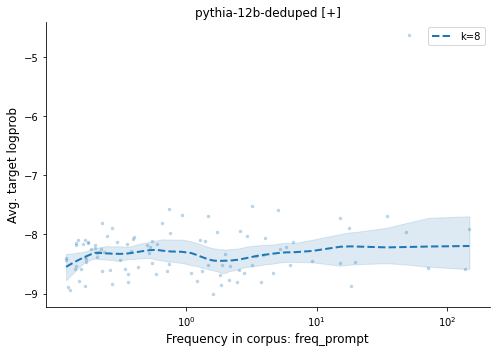

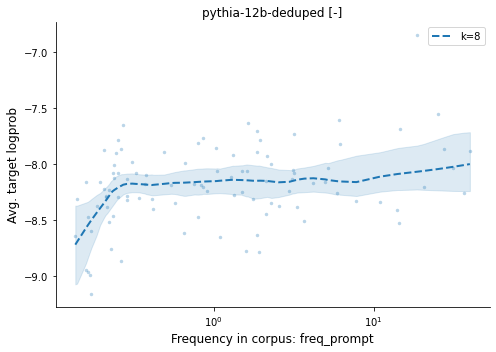

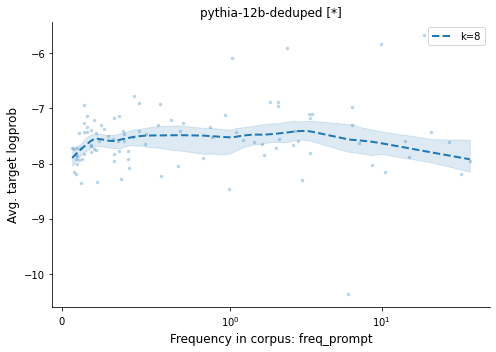

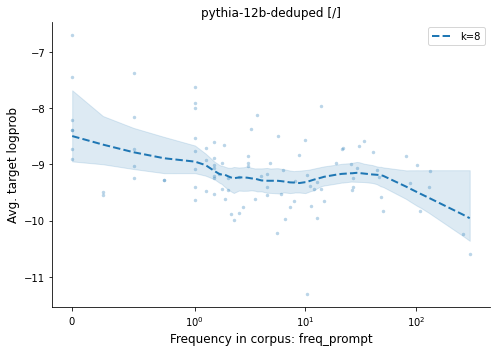

In [39]:
for op in OPS:
    plot_freq_vs_logprob(
        results,
        "EleutherAI/pythia-12b-deduped",
        op=op,
        freq_col="freq_prompt",
        group_col="a"
    )

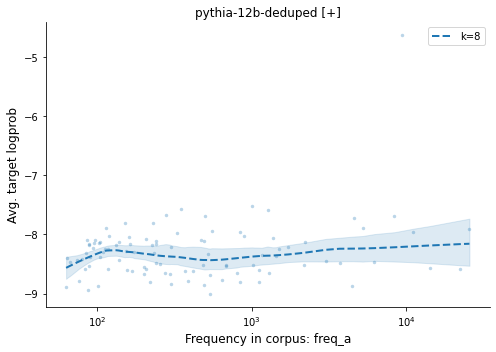

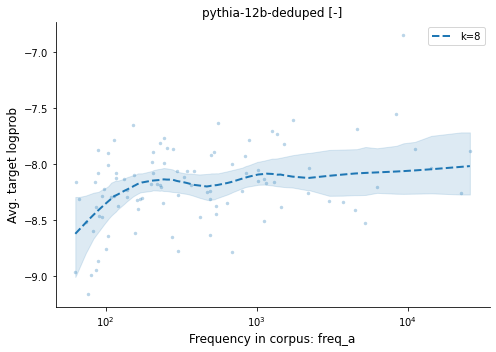

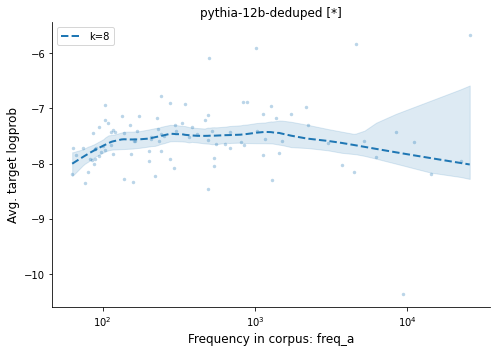

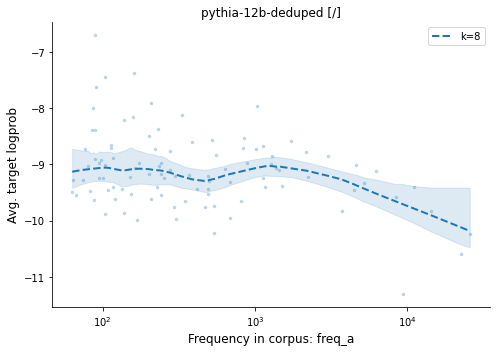

In [40]:
for op in OPS:
    plot_freq_vs_logprob(
        results,
        "EleutherAI/pythia-12b-deduped",
        op=op,
        freq_col="freq_a",
        group_col="a"
    )

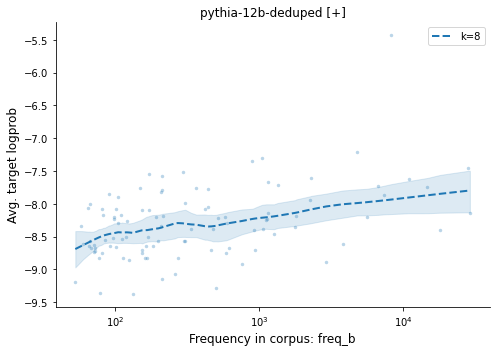

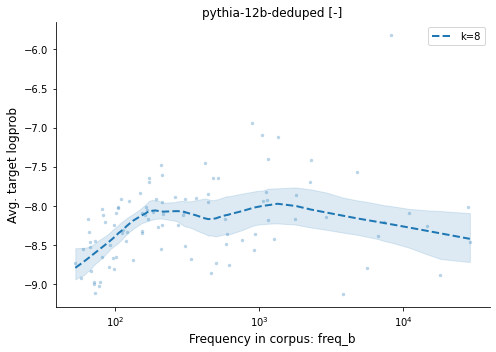

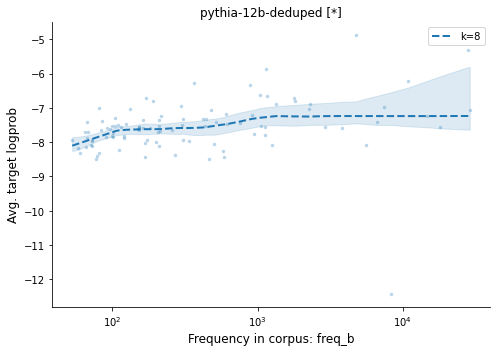

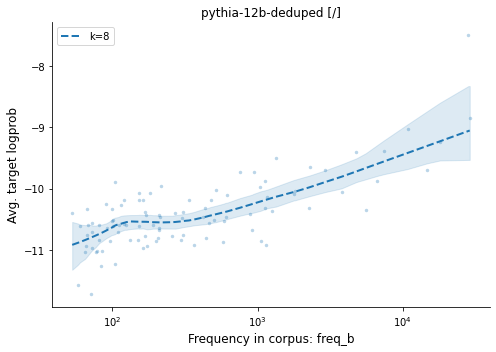

In [41]:
for op in OPS:
    plot_freq_vs_logprob(
        results,
        "EleutherAI/pythia-12b-deduped",
        op=op,
        freq_col="freq_b",
        group_col="b"
    )

In [29]:
print(results["freq_expr"].describe())
print(results["freq_expr"].value_counts().head(20))

count    122288.000000
mean          4.324545
std          71.830926
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        7196.000000
Name: freq_expr, dtype: float64
0     84124
1     16668
2      6452
3      3288
4      2112
5      1380
6      1044
7       720
9       608
8       552
10      420
11      396
12      308
14      256
15      236
13      228
18      180
17      164
16      164
21      128
Name: freq_expr, dtype: int64


In [15]:
import numpy as np
import statsmodels.formula.api as smf

df = results.copy()
df["log_freq_a"] = np.log10(df["freq_a"] + 1)
df["log_freq_b"] = np.log10(df["freq_b"] + 1)
df["abs_c"] = df["c"].astype(int).abs()
df["log_abs_c"] = np.log10(df["abs_c"] + 1)
df["neg_c"] = (df["c"].astype(int) < 0).astype(int)
df["a_int"] = df["a"].astype(int)
df["b_int"] = df["b"].astype(int)

# simple carry / borrow examples
df["carry_add"] = ((df["op"] == "+") & (((df["a_int"] % 10) + (df["b_int"] % 10)) >= 10)).astype(int)
df["borrow_sub"] = ((df["op"] == "-") & ((df["a_int"] % 10) < (df["b_int"] % 10))).astype(int)

m = smf.ols(
    "avg_target_logprob ~ log_freq_a + log_freq_b + log_abs_c + neg_c + C(op) + carry_add + borrow_sub",
    data=df[df["k"] == 8]
).fit()

print(m.summary())

KeyError: 'k'